# 05 — Router: solo Fase 3 (profesor)

Notebook mínimo para entrenar el **VisionRouter** con el flujo del profesor: **logits del experto congelado × gating del router** y pérdida de tarea (`L_task`) + `L_aux`, **sin** ablation, **sin** pruebas dummy, **sin** validación de etiquetas, **sin** warm-up ni fase de partial-unfreeze previa.

**Datos:** misma **Fase 1** que el notebook `03`: ZIPs en `RAW_DIR` (Drive) → descompresión en `LOCAL_DEST` (`/content/datasets/`). Si ya tienes las carpetas descomprimidas, puedes poner `RUN_EXTRACT_ZIPS = False`.

**Expertos:** checkpoints en `WEIGHTS_DIR` (mismos candidatos que en el notebook 03).

**Validación:** embeddings CLS en validación (cache `.npz` o extracción automática la primera vez).


In [1]:
!pip install -q SimpleITK nibabel torch torchvision monai einops timm
import os
import glob
import random
import shutil
import subprocess
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models.video import R3D_18_Weights, r3d_18
from torch.utils.checkpoint import checkpoint as grad_checkpoint
from monai.networks.blocks import PatchEmbed
import timm
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# --- Rutas (igual que notebook 03): ZIPs en Drive → datasets en disco local Colab ---
RAW_DIR = "/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/"
LOCAL_DEST = "/content/datasets/"
WEIGHTS_DIR = "/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/"
FEATURE_DIR = WEIGHTS_DIR
os.makedirs(LOCAL_DEST, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

DATASET_ROOTS = {
    "NIH":      (os.path.join(LOCAL_DEST, "NIH Chest X ray 14"), 0),
    "ISIC":     (os.path.join(LOCAL_DEST, "ISIC 2019"), 1),
    "Osteo":    (os.path.join(LOCAL_DEST, "Knee Osteoarthritis Classification"), 2),
    "LUNA16":   (os.path.join(LOCAL_DEST, "Luna16 Lung Cancer Dataset"), 3),
    "Pancreas": (os.path.join(LOCAL_DEST, "Pancreas Cancer"), 4),
}

print("Rutas (datasets tras extracción en LOCAL_DEST):")
for k, (p, d) in DATASET_ROOTS.items():
    ok = os.path.isdir(p)
    print(f"  {k} id={d} exists={ok} -> {p}")
print(f"RAW_DIR={RAW_DIR}")
print(f"LOCAL_DEST={LOCAL_DEST}")
print(f"WEIGHTS_DIR={WEIGHTS_DIR}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 109.1 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Mounted at /content/drive
Rutas (datasets tras extracción en LOCAL_DEST):
  NIH id=0 exists=False -> /content/datasets/NIH Chest X ray 14
  ISIC id=1 exists=False -> /content/datasets/ISIC 2019
  Osteo id=2 exists=False -> /content/datasets/Knee Osteoarthritis Classification
  LUNA16 id=3 exists=False -> /content/datasets/Luna16 Lung Cancer Dataset
  Pancreas id=4 exists=False -> /content/datasets/Pancreas Cancer
RAW_DIR=/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/
LOCAL_DEST=/content/datasets/
WEIGHTS_DIR=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/


## Fase 1: Extracción de datos a disco local

Copia los `.zip` desde `RAW_DIR` (Google Drive) a `LOCAL_DEST` y los descomprime. **Misma lógica que `03_Pipeline_Router_MoE.ipynb`.**

Pon `RUN_EXTRACT_ZIPS = False` si las carpetas de datasets ya existen en `/content/datasets/`.


In [2]:
def extract_datasets_colab(raw_dir=RAW_DIR, local_dest=LOCAL_DEST):
    """Copia ZIPs de Drive a /content/datasets/ y los descomprime (notebook 03)."""
    if not os.path.exists(raw_dir):
        print(f"Ruta {raw_dir} no existe. No se extrae nada.")
        return
    zip_files = sorted([f for f in os.listdir(raw_dir) if f.lower().endswith(".zip")])
    print(f"Encontrados {len(zip_files)} zips.")
    for zip_name in zip_files:
        print("=" * 60)
        print(f"Procesando: {zip_name}")
        drive_zip_path = os.path.join(raw_dir, zip_name)
        dataset_name = os.path.splitext(zip_name)[0]
        unzip_dir = os.path.join(local_dest, dataset_name)
        local_zip_path = os.path.join(local_dest, zip_name)
        if os.path.isdir(unzip_dir) and len(os.listdir(unzip_dir)) > 0:
            print(f" Ya existe: {unzip_dir} (omitido).")
            continue
        print(" 1. Copiando ZIP...")
        shutil.copy2(drive_zip_path, local_zip_path)
        os.makedirs(unzip_dir, exist_ok=True)
        print(f" 2. Descomprimiendo en {unzip_dir}...")
        subprocess.run(["unzip", "-q", local_zip_path, "-d", unzip_dir], check=True)
        print(" 3. Borrando ZIP local.")
        os.remove(local_zip_path)
        # ZIPs internos
        for iz in glob.glob(os.path.join(unzip_dir, "**", "*.zip"), recursive=True):
            print(f" -> ZIP interno: {iz}")
            subprocess.run(["unzip", "-q", iz, "-d", os.path.dirname(iz)], check=True)
            os.remove(iz)
    print("\nExtracción completa.")


RUN_EXTRACT_ZIPS = True  # False si ya descomprimiste en esta sesión
if RUN_EXTRACT_ZIPS:
    extract_datasets_colab()
else:
    print("RUN_EXTRACT_ZIPS=False: se asume que LOCAL_DEST ya contiene los datasets.")


Encontrados 5 zips.
Procesando: ISIC 2019.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/ISIC 2019...
 3. Borrando ZIP local.
Procesando: Knee Osteoarthritis Classification.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/Knee Osteoarthritis Classification...
 3. Borrando ZIP local.
Procesando: Luna16 Lung Cancer Dataset.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/Luna16 Lung Cancer Dataset...
 3. Borrando ZIP local.
Procesando: NIH Chest X ray 14.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/NIH Chest X ray 14...
 3. Borrando ZIP local.
Procesando: Pancreas Cancer.zip
 1. Copiando ZIP...
 2. Descomprimiendo en /content/datasets/Pancreas Cancer...
 3. Borrando ZIP local.
 -> ZIP interno: /content/datasets/Pancreas Cancer/batch_1.zip

Extracción completa.


In [3]:
# =============================================================================
# Arquitecturas de los 5 expertos (embebido en el notebook; sin .py externo)
# =============================================================================

import os
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import timm
import torchvision.models as models
from torchvision.models.video import R3D_18_Weights, r3d_18


# ============================================================================
# Experto 1 (NIH) - Swin-Tiny (NIH_ChestXray_Swin_Tiny_Training.ipynb)
# 5 clases multietiqueta (Mass, Nodule, Effusion, Cardiomegaly, Pneumothorax).
# Pesos: suele guardarse como Experts_2D/MaxViT_NIH_5cls.pth (nombre historico en CONFIG).
# ============================================================================
class SwinNIHClassifier(nn.Module):
    """Misma envoltura que SwinClassifier en el notebook de entrenamiento (timm)."""

    def __init__(self, num_classes: int = 5, pretrained: bool = True):
        super().__init__()
        self.model = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=num_classes,
        )

    def forward(self, x):
        return self.model(x)


# ============================================================================
# Experto 3 (Osteo) - VGG16-BN
# ============================================================================
def build_vgg16_bn(num_classes: int = 5, pretrained: bool = True):
    model = models.vgg16_bn(weights="IMAGENET1K_V1" if pretrained else None)
    old_conv = model.features[0]
    new_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)
    with torch.no_grad():
        new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        new_conv.bias.copy_(old_conv.bias)
    model.features[0] = new_conv
    model.classifier = nn.Sequential(
        nn.Linear(512 * 7 * 7, 512),
        nn.ReLU(True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(True),
        nn.BatchNorm1d(256),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


# ============================================================================
# Experto 4 (LUNA16 3D) — R3D-18 Kinetics 3ch (LUNA16_R3D18_Training.ipynb)
# Experto 5 (Pancreas 3D) — R3D18 entrada 1 canal (stem adaptado)
# ============================================================================
from torch.utils.checkpoint import checkpoint as grad_checkpoint


class R3D18LunaKineticsExpert(nn.Module):
    """R3D-18 torchvision binario: 3 canales con stats Kinetics (ver luna_1ch_to_kinetics_3ch)."""

    def __init__(self, num_classes: int = 2, pretrained: bool = True):
        super().__init__()
        weights = R3D_18_Weights.DEFAULT if pretrained else None
        base = r3d_18(weights=weights)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head = nn.Linear(512, num_classes)

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head(feat)


class R3D18Expert(nn.Module):
    """R3D-18 para 3D binario (Exp5 Pancreas): entrada 1 canal."""

    def __init__(self, num_classes: int = 2, pretrained: bool = True):
        super().__init__()
        weights = R3D_18_Weights.DEFAULT if pretrained else None
        base = r3d_18(weights=weights)
        old_conv = base.stem[0]
        stem_conv = nn.Conv3d(
            1,
            64,
            kernel_size=(3, 7, 7),
            stride=(1, 2, 2),
            padding=(1, 3, 3),
            bias=False,
        )
        with torch.no_grad():
            stem_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        base.stem[0] = stem_conv
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head = nn.Linear(512, num_classes)

    def forward(self, x):
        # Gradient checkpointing obligatorio para expertos 3D (consigna §8.1)
        for block in self.backbone:
            x = grad_checkpoint(block, x, use_reentrant=False)
        return self.head(x.flatten(1))


# ============================================================================
# Factory y carga de pesos
# ============================================================================
import glob
import subprocess

EXPERT_SPECS = {
    1: {"name": "exp1_nih", "num_classes": 5, "arch": "swin_tiny_nih"},
    2: {"name": "exp2_isic", "num_classes": 9, "arch": "efficientnet_b3"},
    3: {"name": "exp3_osteo", "num_classes": 5, "arch": "vgg16_bn"},
    4: {
        "name": "exp4_luna16",
        "model_name": "R3D-18 (Kinetics 3ch)",
        "num_classes": 2,
        "arch": "r3d18_luna",
    },
    5: {"name": "exp5_pancreas", "num_classes": 2, "arch": "r3d18"},
}


def build_expert(expert_id: int, pretrained_backbone: bool = True):
    spec = EXPERT_SPECS[int(expert_id)]
    arch = spec["arch"]
    num_classes = spec["num_classes"]

    if arch == "swin_tiny_nih":
        return SwinNIHClassifier(num_classes=num_classes, pretrained=pretrained_backbone)
    if arch == "efficientnet_b3":
        return timm.create_model("efficientnet_b3", pretrained=pretrained_backbone, num_classes=num_classes)
    if arch == "vgg16_bn":
        return build_vgg16_bn(num_classes=num_classes, pretrained=pretrained_backbone)
    if arch == "r3d18_luna":
        return R3D18LunaKineticsExpert(num_classes=num_classes, pretrained=pretrained_backbone)
    if arch == "r3d18":
        return R3D18Expert(num_classes=num_classes, pretrained=pretrained_backbone)
    raise ValueError(f"Arquitectura no soportada: {arch}")


def _default_checkpoint_candidates(weights_dir: str) -> Dict[int, List[str]]:
    """
    Candidatos por experto para tolerar nombres antiguos/nuevos de checkpoints.
    """
    return {
        1: [
            os.path.join(weights_dir, "Experts_2D", "MaxViT_NIH_5cls.pth"),
            os.path.join(weights_dir, "MaxViT_NIH_5cls.pth"),
            os.path.join(weights_dir, "exp1_NIH_SwinTiny_best.pth"),
            os.path.join(weights_dir, "exp1_NIH_LungMaxViT_best.pth"),
        ],
        2: [
            os.path.join(weights_dir, "exp2_ISIC_EfficientNetB3_best.pth"),
        ],
        3: [
            os.path.join(weights_dir, "exp3_Osteo_VGG16BN_best.pth"),
        ],
        4: [
            # Mismas rutas que antes; pesos del entrenamiento LUNA R3D-18 (expert4_*_best.pth)
            os.path.join(weights_dir, "exp4_LUNA16_3D_best.pth"),
        ],
        5: [
            os.path.join(weights_dir, "exp5_Pancreas_3D_best.pth"),
            os.path.join(weights_dir, "r3d18_pancreas_best_V2.pth"),
        ],
    }


def resolve_checkpoint(candidates: List[str]) -> str:
    """
    Busca el checkpoint. Si existe ``<ruta>.pth.zip`` y no el ``.pth``,
    descomprime en el mismo directorio y devuelve la ruta del ``.pth``.
    """
    for p in candidates:
        if any(ch in p for ch in ["*", "?", "["]):
            matches = sorted(glob.glob(p))
            if matches:
                return matches[0]
        if os.path.exists(p):
            return p
        zip_path = p + ".zip"
        if os.path.exists(zip_path):
            print(f"📦 Detectado peso comprimido: {os.path.basename(zip_path)}")
            extract_dir = os.path.dirname(zip_path) or "."
            try:
                print(f"  → Descomprimiendo en {extract_dir}...")
                subprocess.run(["unzip", "-o", zip_path, "-d", extract_dir], check=True)
                if os.path.exists(p):
                    print(f"  ✅ Checkpoint extraído: {os.path.basename(p)}")
                    return p
                new_matches = glob.glob(os.path.join(extract_dir, "*.pth"))
                if new_matches:
                    return sorted(new_matches)[0]
            except Exception as e:
                print(f"  ❌ Error al descomprimir {zip_path}: {e}")
    return ""


def load_weights(model: nn.Module, ckpt_path: str, map_location: str = "cpu", strict: bool = False):
    if not ckpt_path or not os.path.exists(ckpt_path):
        return False, "checkpoint no encontrado"
    raw = torch.load(ckpt_path, map_location=map_location)

    # Checkpoints de entrenamiento suelen ser dict con 'state_dict'
    if isinstance(raw, dict):
        if "state_dict" in raw:
            state = raw["state_dict"]
        elif "model_state_dict" in raw:
            state = raw["model_state_dict"]
        elif "model" in raw and isinstance(raw["model"], dict):
            state = raw["model"]
        else:
            state = raw
    else:
        state = raw

    try:
        model.load_state_dict(state, strict=strict)
        return True, "ok"
    except Exception as e:
        return False, f"load_state_dict fallo: {e}"

def freeze_and_eval(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    return model


def load_all_experts_from_drive(
    weights_dir: str,
    device: str = "cpu",
    strict: bool = False,
    pretrained_backbone: bool = False,
) -> Tuple[Dict[int, nn.Module], Dict[int, dict]]:
    """
    Crea y carga los 5 expertos con pesos desde Drive.

    Retorna:
      experts: dict[int, nn.Module]
      info: dict[int, {arch, ckpt, loaded, params}]
    """
    candidates = _default_checkpoint_candidates(weights_dir)
    experts = {}
    info = {}

    for eid in sorted(EXPERT_SPECS.keys()):
        model = build_expert(eid, pretrained_backbone=pretrained_backbone)
        ckpt_path = resolve_checkpoint(candidates[eid])
        loaded, msg = load_weights(model, ckpt_path, map_location="cpu", strict=strict)

        model = freeze_and_eval(model).to(device)
        experts[eid] = model
        spec = EXPERT_SPECS[eid]
        info[eid] = {
            "name": spec["name"],
            "arch": spec["arch"],
            "model_name": spec.get("model_name", ""),
            "ckpt": ckpt_path,
            "loaded": loaded,
            "message": msg,
            "params": int(sum(p.numel() for p in model.parameters())),
        }

    return experts, info


def print_expert_load_report(info: Dict[int, dict]):
    print("=== Expert Load Report ===")
    for eid in sorted(info.keys()):
        row = info[eid]
        status = "OK" if row["loaded"] else "MISSING"
        mn = row.get("model_name") or ""
        mn_s = f" | {mn}" if mn else ""
        print(
            f"Exp{eid} | {row['name']} | arch={row['arch']}{mn_s} | {status} | "
            f"params={row['params']:,} | ckpt={row['ckpt'] or 'N/A'}"
        )
print("Arquitecturas de expertos: definidas en el notebook.")


Arquitecturas de expertos: definidas en el notebook.


In [4]:
class AdaptivePreprocessor:
    """Carga archivos y retorna tensores nativos (2D o 3D)."""
    def __init__(
        self,
        size_2d=(224, 224),
        size_3d=(64, 64, 64),
        hu_window_ct=(-1000, 400),
        use_clahe_nih_osteo=True,
        use_imagenet_norm_2d=True,
    ):
        self.size_2d = size_2d
        self.size_3d = size_3d
        self.hu_min, self.hu_max = hu_window_ct
        self.use_clahe_nih_osteo = use_clahe_nih_osteo
        self.use_imagenet_norm_2d = use_imagenet_norm_2d
        self.imagenet_mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
        self.imagenet_std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)

    def __call__(self, file_path):
        ext = file_path.lower()
        if ext.endswith(('.png', '.jpg', '.jpeg')): return self._process_2d(file_path)
        if ext.endswith('.mha'):                     return self._process_mha(file_path)
        if ext.endswith(('.mhd', '.nii.gz', '.nii')): return self._process_3d(file_path)
        raise ValueError(f'Formato no soportado: {file_path}')

    def _is_nih_or_osteo(self, path: str) -> tuple[bool, bool]:
        p = str(path).replace('\\', '/').lower()
        is_nih = ('nih chest x ray 14' in p) or ('/nih/' in p)
        is_osteo = ('knee osteoarthritis classification' in p) or ('/klgrade/' in p) or ('/osteo' in p)
        return is_nih, is_osteo

    def _clahe_nih_rgb(self, img_rgb_u8: np.ndarray) -> np.ndarray:
        lab = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        hist = cv2.calcHist([l], [0], None, [256], [0, 256]).flatten()
        peaks = int(np.sum(hist > hist.mean()))
        tile_size = max(2, int(np.ceil(np.log(max(peaks, 2)))))
        valleys = hist[hist <= hist.mean()]
        val_mean = float(valleys.mean()) if len(valleys) > 0 else 1.0
        clip = float(np.clip(hist.max() / (val_mean + 1e-6), 1.0, 4.0))
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile_size, tile_size))
        l_eq = clahe.apply(l)
        lab_eq = cv2.merge((l_eq, a, b))
        arr_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
        return cv2.GaussianBlur(arr_eq, (5, 5), sigmaX=1.0)

    def _clahe_osteo_gray_to_rgb(self, img_rgb_u8: np.ndarray) -> np.ndarray:
        g = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2GRAY)
        hist = cv2.calcHist([g], [0], None, [256], [0, 256]).flatten()
        tile_size = max(2, int(np.ceil(np.log(max(int(np.sum(hist > hist.mean())), 2)))))
        valleys = hist[hist <= hist.mean()]
        val_mean = float(valleys.mean()) if len(valleys) > 0 else 1.0
        clip = float(np.clip(hist.max() / (val_mean + 1e-6), 1.0, 4.0))
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile_size, tile_size))
        enhanced = clahe.apply(g)
        return np.repeat(enhanced[:, :, None], 3, axis=2)

    def _apply_imagenet_norm_2d(self, t: torch.Tensor) -> torch.Tensor:
        if not self.use_imagenet_norm_2d:
            return t
        mean = self.imagenet_mean.to(dtype=t.dtype, device=t.device)
        std = self.imagenet_std.to(dtype=t.dtype, device=t.device)
        return (t - mean) / std

    def _process_2d(self, path):
        is_nih, is_osteo = self._is_nih_or_osteo(path)
        img = Image.open(path).convert('RGB').resize(self.size_2d)
        arr = np.array(img, dtype=np.uint8)

        if self.use_clahe_nih_osteo:
            if is_nih:
                arr = self._clahe_nih_rgb(arr)
            elif is_osteo:
                arr = self._clahe_osteo_gray_to_rgb(arr)

        t = torch.from_numpy(arr.astype(np.float32) / 255.0).permute(2, 0, 1).contiguous()
        return self._apply_imagenet_norm_2d(t)

    def _process_mha(self, path):
        itk_img = sitk.ReadImage(path)
        size = itk_img.GetSize()
        arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        if len(size) == 2:                       return self._array_2d_to_tensor(arr, path_hint=path)
        if len(size) == 3 and size[2] <= 1:
            arr = np.squeeze(arr)
            if arr.ndim == 2:                    return self._array_2d_to_tensor(arr, path_hint=path)
        return self._volume_array_to_tensor(arr, path)

    def _array_2d_to_tensor(self, arr, path_hint=''):
        if arr.max() > 1.5:
            arr = arr / 255.0 if arr.max() > 2.0 else (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        arr = arr.astype(np.float32)
        t = torch.from_numpy(arr).unsqueeze(0)
        if t.shape[1:] != torch.Size(self.size_2d):
            t = F.interpolate(t.unsqueeze(0), size=self.size_2d, mode='bilinear', align_corners=False).squeeze(0)

        # Para 2D, el router trabaja en 3 canales + normalización ImageNet.
        if t.shape[0] == 1:
            t = t.repeat(3, 1, 1)
        elif t.shape[0] > 3:
            t = t[:3]
        t = t.clamp(0.0, 1.0)
        return self._apply_imagenet_norm_2d(t)

    def _volume_array_to_tensor(self, img_arr, path_hint=''):
        amin, amax = float(np.nanmin(img_arr)), float(np.nanmax(img_arr))
        pre_norm = amax <= 1.5 and amin >= -1e-2 and 'Pancreas' in str(path_hint).replace('\\', '/')
        if not pre_norm:
            img_arr = np.clip(img_arr, self.hu_min, self.hu_max)
            img_arr = (img_arr - self.hu_min) / (self.hu_max - self.hu_min + 1e-8)
        else:
            img_arr = np.clip(img_arr, 0.0, 1.0)
        t = torch.tensor(img_arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=self.size_3d, mode='trilinear', align_corners=False)
        return t.squeeze(0)  # [1, 64, 64, 64]

    def _process_3d(self, path):
        if path.endswith('.mhd'):
            itk_img = sitk.ReadImage(path)
            img_arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        else:
            nii_img = nib.load(path)
            img_arr = np.transpose(nii_img.get_fdata().astype(np.float32), (2, 1, 0))
        return self._volume_array_to_tensor(img_arr, path_hint=path)

preprocessor = AdaptivePreprocessor()
print('AdaptivePreprocessor listo.')

# --- Experto LUNA (R3D-18): AdaptivePreprocessor da [1,64³]; el modelo usa 3ch + stats Kinetics (LUNA16_R3D18_Training) ---
KINETICS_MEAN = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1, 1)
KINETICS_STD = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1, 1)


def luna_1ch_to_kinetics_3ch(t, device=None):
    """[B,1,D,H,W] en [0,1] → [B,3,D,H,W] con normalización Kinetics-400."""
    if device is None:
        device = t.device
    mean = KINETICS_MEAN.to(device=device, dtype=t.dtype)
    std = KINETICS_STD.to(device=device, dtype=t.dtype)
    t3 = t.expand(-1, 3, -1, -1, -1)
    return (t3 - mean) / std


VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.mha', '.mhd', '.nii', '.nii.gz')

def scan_dataset_files(root_path, max_files=None):
    """Escanea recursivamente y retorna paths de archivos médicos válidos."""
    files = []
    for dirpath, _, filenames in os.walk(root_path):
        for fname in sorted(filenames):
            if fname.lower().endswith(VALID_EXTENSIONS):
                files.append(os.path.join(dirpath, fname))
    if max_files:
        files = files[:max_files]
    return files

# (opcional) contar archivos:
# for name, (path, did) in DATASET_ROOTS.items():
#     print(name, len(scan_dataset_files(path)) if os.path.isdir(path) else 'missing')


AdaptivePreprocessor listo.


In [5]:
# =============================================================================
# Filtrado NIH: solo imágenes con al menos una de las 5 clases del Experto 1
# =============================================================================
import pandas as pd

NIH_EXPERT_5_CLASSES = {"Mass", "Nodule", "Effusion", "Cardiomegaly", "Pneumothorax"}


def build_nih_filtered_fileset(nih_root: str) -> set:
    """
    Lee el CSV de NIH y retorna un set con los nombres de archivo (basename)
    que tienen al menos una de las 5 clases del Experto 1.
    Si el CSV no se encuentra, retorna set vacío (sin filtro).
    """
    csv_candidates = glob.glob(os.path.join(nih_root, "**", "*.csv"), recursive=True)
    nih_csv = next(
        (
            c
            for c in csv_candidates
            if "data_entry" in os.path.basename(c).lower() and "2017" in os.path.basename(c).lower()
        ),
        None,
    )
    if nih_csv is None:
        print("  [NIH filter] CSV no encontrado → sin filtro aplicado.")
        return set()

    try:
        df = pd.read_csv(nih_csv)
    except Exception:
        print("  [NIH filter] no se pudo leer el CSV → sin filtro aplicado.")
        return set()
    if "Image Index" not in df.columns or "Finding Labels" not in df.columns:
        print("  [NIH filter] CSV inválido → sin filtro aplicado.")
        return set()

    valid_filenames = set()
    for _, row in df.iterrows():
        labels = {l.strip() for l in str(row["Finding Labels"]).split("|") if l.strip()}
        if labels & NIH_EXPERT_5_CLASSES:
            valid_filenames.add(str(row["Image Index"]))

    print(f"  [NIH filter] {len(valid_filenames):,} imágenes con al menos 1 de {NIH_EXPERT_5_CLASSES}")
    return valid_filenames


def _shannon_entropy_gray(path: str):
    try:
        arr = np.array(Image.open(path).convert('L'))
        hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
        hist = hist[hist > 0]
        return float(-(hist * np.log2(hist)).sum())
    except Exception:
        return None


def filter_files_by_entropy(file_list, *, min_entropy=4.0, max_entropy=None, name='dataset'):
    """
    Filtra por entropía de Shannon (gris).
    - descarta entropía < min_entropy (ruido/fondo plano)
    - opcional: descarta entropía > max_entropy
    """
    if not file_list:
        return file_list

    kept = []
    low_drop = 0
    high_drop = 0
    fail = 0

    for fp in file_list:
        ent = _shannon_entropy_gray(fp)
        if ent is None:
            fail += 1
            continue
        if min_entropy is not None and ent < float(min_entropy):
            low_drop += 1
            continue
        if max_entropy is not None and ent > float(max_entropy):
            high_drop += 1
            continue
        kept.append(fp)

    print(
        f"  [{name}] entropy filter: in={len(file_list):,} | keep={len(kept):,} | "
        f"drop_low={low_drop:,} | drop_high={high_drop:,} | fail={fail:,}"
    )
    return kept


print("Filtro NIH (5 clases del Experto 1) + utilidades de entropía definidos.")


Filtro NIH (5 clases del Experto 1) + utilidades de entropía definidos.


In [6]:
import pandas as pd

# -------- Etiquetas por dataset (misma lógica de notebooks de expertos) --------
NIH_CLASSES_14 = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
ISIC_CLASSES_8 = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']


def _safe_read_csv(path):
    try:
        return pd.read_csv(path)
    except Exception:
        return None


def _normalize_luna_ann_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    lower = {c.lower(): c for c in df.columns}
    if 'seriesuid' not in lower and 'seriesinstanceuid' in lower:
        df = df.rename(columns={lower['seriesinstanceuid']: 'seriesuid'})
    return df


def build_dataset_label_index(roots):
    """
    Construye índices de etiquetas por dataset para usar en el loader mixto.
    - NIH: multi-label (14) desde Data_Entry* (Finding Labels).
    - ISIC: single-label (8) desde CSV one-hot (MEL..SCC), excluye UNK.
    - Osteo: clase KL desde carpeta padre (0..4).
    - LUNA16: binario scan-level desde annotations.csv (como LUNA16_R3D18_Training); fallback candidates*.csv.
    - Pancreas: label en NPZ (si aplica) o inferencia por nombre/ruta.
    """
    idx = {'nih': {}, 'isic': {}, 'osteo': {}, 'luna16': {}, 'meta': {}}

    # NIH
    nih_root = roots.get('NIH', (None, None))[0]
    if nih_root and os.path.isdir(nih_root):
        nih_csv = None
        for c in glob.glob(os.path.join(nih_root, '**', '*.csv'), recursive=True):
            bn = os.path.basename(c).lower()
            if 'data_entry' in bn and '2017' in bn:
                nih_csv = c
                break
        if nih_csv:
            df = _safe_read_csv(nih_csv)
            if df is not None and 'Image Index' in df.columns and 'Finding Labels' in df.columns:
                for _, r in df.iterrows():
                    img = str(r['Image Index'])
                    labels_txt = str(r['Finding Labels'])
                    vec = np.zeros(len(NIH_CLASSES_14), dtype=np.float32)
                    toks = [t.strip() for t in labels_txt.split('|') if t.strip()]
                    for i, cls in enumerate(NIH_CLASSES_14):
                        vec[i] = 1.0 if cls in toks else 0.0
                    idx['nih'][img] = vec
                idx['meta']['nih_csv'] = nih_csv

    # ISIC
    isic_root = roots.get('ISIC', (None, None))[0]
    if isic_root and os.path.isdir(isic_root):
        isic_csv = None
        for c in glob.glob(os.path.join(isic_root, '**', '*.csv'), recursive=True):
            df = _safe_read_csv(c)
            if df is not None and all(col in df.columns for col in ISIC_CLASSES_8):
                isic_csv = c
                break
        if isic_csv:
            df = _safe_read_csv(isic_csv)
            if df is not None:
                if 'UNK' in df.columns:
                    df = df[df['UNK'] != 1.0].reset_index(drop=True)
                img_col = df.columns[0]
                avail = [c for c in ISIC_CLASSES_8 if c in df.columns]
                for _, r in df.iterrows():
                    name = str(r[img_col])
                    row = r[avail].to_numpy(dtype=np.float32)
                    if len(row) == len(ISIC_CLASSES_8):
                        lbl = int(np.argmax(row))
                        idx['isic'][name] = lbl
                idx['meta']['isic_csv'] = isic_csv

    # Osteoarthritis: indice explicito identico al notebook de entrenamiento
    # Estructura: root/KLGrade/KLGrade/0..4/imagen.jpg (o .mha tras conversion)
    osteo_root = roots.get('Osteo', (None, None))[0]
    if osteo_root and os.path.isdir(osteo_root):
        # Intenta la ruta doble KLGrade/KLGrade (estructura original del zip)
        klgrade_dir = os.path.join(osteo_root, 'KLGrade', 'KLGrade')
        if not os.path.isdir(klgrade_dir):
            # Fallback: puede estar ya en la raiz o un nivel
            klgrade_dir = os.path.join(osteo_root, 'KLGrade')
        if not os.path.isdir(klgrade_dir):
            klgrade_dir = osteo_root
        for grade_folder in sorted(os.listdir(klgrade_dir)):
            gp = os.path.join(klgrade_dir, grade_folder)
            if not os.path.isdir(gp):
                continue
            try:
                grade = int(grade_folder)
            except ValueError:
                continue
            if grade not in [0, 1, 2, 3, 4]:
                continue
            for fname in os.listdir(gp):
                fpath = os.path.normpath(os.path.join(gp, fname))
                idx['osteo'][fpath] = grade
        idx['meta']['osteo_dir'] = klgrade_dir

    # LUNA16: scan-level (LUNA16_R3D18_Training): annotations.csv + un .mhd por UID
    luna_root = roots.get('LUNA16', (None, None))[0]
    if luna_root and os.path.isdir(luna_root):
        all_csv = glob.glob(os.path.join(luna_root, '**', '*.csv'), recursive=True)
        ann_path = os.path.join(luna_root, 'annotations.csv')
        if not os.path.isfile(ann_path):
            ann_path = next(
                (
                    c
                    for c in all_csv
                    if 'annotations' in os.path.basename(c).lower()
                    and 'excluded' not in os.path.basename(c).lower()
                ),
                None,
            )
        mhd_files = glob.glob(os.path.join(luna_root, '**', '*.mhd'), recursive=True)
        if ann_path and os.path.isfile(str(ann_path)) and mhd_files:
            ann = _safe_read_csv(ann_path)
            if ann is not None:
                ann = _normalize_luna_ann_columns(ann)
                if 'seriesuid' in ann.columns:
                    ann['seriesuid'] = ann['seriesuid'].astype(str).str.strip()
                    positive_uids = set(ann['seriesuid'].values)
                    lmap = {}
                    for mhd in mhd_files:
                        uid = str(os.path.splitext(os.path.basename(mhd))[0]).strip()
                        lmap[uid] = 1 if uid in positive_uids else 0
                    idx['luna16'] = lmap
                    idx['meta']['luna_annotations_csv'] = ann_path
        if not idx['luna16']:
            cand = next((c for c in all_csv if 'candidates_v2' in os.path.basename(c).lower()), None)
            if cand is None:
                cand = next((c for c in all_csv if 'candidates' in os.path.basename(c).lower()), None)
            if cand:
                df = _safe_read_csv(cand)
                if df is not None:
                    cols_map = {c.lower(): c for c in df.columns}
                    if 'seriesuid' in cols_map and 'class' in cols_map:
                        s_col = cols_map['seriesuid']
                        c_col = cols_map['class']
                        df[c_col] = pd.to_numeric(df[c_col], errors='coerce').fillna(0).astype(int)
                        agg = df.groupby(s_col)[c_col].max().to_dict()
                        idx['luna16'] = {str(k): int(v) for k, v in agg.items()}
                        idx['meta']['luna_csv'] = cand

    return idx


def _infer_osteo_label_from_path(path):
    parts = os.path.normpath(path).split(os.sep)
    for p in reversed(parts):
        if p.isdigit() and int(p) in [0, 1, 2, 3, 4]:
            return int(p)
        up = p.upper()
        if up.startswith('KL') and up[2:].isdigit():
            v = int(up[2:])
            if v in [0, 1, 2, 3, 4]:
                return v
    return None


def _infer_pancreas_label_from_path_or_npz(path):
    low = path.lower()
    if low.endswith('.npz'):
        try:
            d = np.load(path)
            if 'label' in d:
                return int(d['label'])
            if 'y' in d:
                return int(d['y'])
        except Exception:
            pass
    # fallback por nombre/carpeta
    pos_tokens = ['cancer', 'tumor', 'positive', 'pdac', 'malig']
    neg_tokens = ['normal', 'negative', 'benign', 'non_tumor']
    if any(t in low for t in pos_tokens):
        return 1
    if any(t in low for t in neg_tokens):
        return 0
    return None


def resolve_task_label(path, dataset_id, label_index):
    """Devuelve etiqueta de tarea por muestra según dataset experto."""
    p = os.path.normpath(path)
    fname = os.path.basename(p)
    stem = os.path.splitext(fname)[0]

    if dataset_id == 0:  # NIH multilabel (14)
        vec = label_index['nih'].get(fname)
        if vec is None:
            # fallback por stem por si hay extensión distinta
            for k, v in label_index['nih'].items():
                if os.path.splitext(k)[0] == stem:
                    vec = v
                    break
        return vec

    if dataset_id == 1:  # ISIC 8 clases
        lbl = label_index['isic'].get(stem)
        if lbl is None:
            # fallback si viene con .jpg en el CSV
            lbl = label_index['isic'].get(fname)
        return lbl

    if dataset_id == 2:  # Osteo KL — indice explicito primero, heuristica como fallback
        lbl = label_index.get('osteo', {}).get(p)
        if lbl is None:
            lbl = _infer_osteo_label_from_path(p)
        return lbl

    if dataset_id == 3:  # LUNA16 binario por seriesuid
        seriesuid = stem
        return label_index['luna16'].get(seriesuid)

    if dataset_id == 4:  # Pancreas binario
        return _infer_pancreas_label_from_path_or_npz(p)

    return None


class MixedMedicalDataset(torch.utils.data.Dataset):
    """Dataset unificado: mezcla 2D/3D y opcionalmente devuelve etiqueta de tarea por dataset."""
    def __init__(self, file_list, dataset_ids, preprocessor, label_index=None, include_task_label=False):
        self.file_list = file_list
        self.dataset_ids = dataset_ids
        self.preprocessor = preprocessor
        self.label_index = label_index
        self.include_task_label = include_task_label

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath = self.file_list[idx]
        did = int(self.dataset_ids[idx])
        tensor = self.preprocessor(fpath)
        if not self.include_task_label:
            return tensor, did

        tlabel = resolve_task_label(fpath, did, self.label_index if self.label_index is not None else {})
        return tensor, did, tlabel, fpath


def mixed_collate_fn(batch):
    """
    Collate personalizado (Punto C).
    - modo clásico: retorna (tensors, dataset_ids)
    - modo extendido: retorna (tensors, dataset_ids, task_labels, paths)
    """
    tensors = [b[0] for b in batch]
    dataset_ids = torch.tensor([b[1] for b in batch], dtype=torch.long)

    if len(batch[0]) == 2:
        return tensors, dataset_ids

    task_labels = [b[2] for b in batch]
    paths = [b[3] for b in batch]
    return tensors, dataset_ids, task_labels, paths

def build_router_dataloader_weighted(
    roots,
    preprocessor,
    *,
    batch_size=8,
    num_workers=2,
    sample_cap=1000,
    include_task_label: bool = False,
    entropy_min: float = 4.0,
    entropy_max: float | None = None,
):
    """Loader balanceado por WeightedRandomSampler.

    include_task_label=True: el batch devuelve (tensors, expert_ids, task_labels, paths)
    lo que activa el flujo del profesor en train_router_one_epoch.
    NIH: filtra a imágenes con al menos una de las 5 clases del Experto 1.
    NIH y Osteo: aplica filtro de entropía antes del muestreo.
    """
    all_files, all_ids = [], []
    nih_root = roots.get("NIH", (None, None))[0]
    nih_valid_set = build_nih_filtered_fileset(nih_root) if nih_root and os.path.isdir(nih_root) else set()

    for name, (path, did) in roots.items():
        files = scan_dataset_files(path)

        if name == "NIH" and nih_valid_set:
            before = len(files)
            files = [f for f in files if os.path.basename(f) in nih_valid_set]
            print(f"  [NIH] filtrado clases experto: {before:,} → {len(files):,}")

        if name in ("NIH", "Osteo"):
            files = filter_files_by_entropy(
                files,
                min_entropy=entropy_min,
                max_entropy=entropy_max,
                name=name,
            )

        if sample_cap is not None and len(files) > sample_cap:
            random.seed(42)
            files = random.sample(files, sample_cap)

        all_files.extend(files)
        all_ids.extend([did] * len(files))
        print(f"[{name}] n={len(files)} (id={did})")

    label_index = build_dataset_label_index(roots) if include_task_label else None
    dataset = MixedMedicalDataset(
        all_files, all_ids, preprocessor,
        label_index=label_index,
        include_task_label=include_task_label,
    )

    counts = Counter(all_ids)
    weights = [1.0 / counts[did] for did in all_ids]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(weights, dtype=torch.double),
        num_samples=len(all_ids),
        replacement=True,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        collate_fn=mixed_collate_fn,
        num_workers=num_workers,
        pin_memory=True,
    )
    print(f'Loader balanceado listo: N={len(dataset)}, batch_size={batch_size}, task_labels={include_task_label}')
    print(f'Conteo por dominio: {dict(counts)}')
    return loader, counts

print('Dataset + build_router_dataloader_weighted listo.')


Dataset + build_router_dataloader_weighted listo.


In [7]:
import pandas as pd

# -------- Etiquetas por dataset (misma lógica de notebooks de expertos) --------
NIH_CLASSES_14 = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
ISIC_CLASSES_8 = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']


def _safe_read_csv(path):
    try:
        return pd.read_csv(path)
    except Exception:
        return None


def _normalize_luna_ann_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    lower = {c.lower(): c for c in df.columns}
    if 'seriesuid' not in lower and 'seriesinstanceuid' in lower:
        df = df.rename(columns={lower['seriesinstanceuid']: 'seriesuid'})
    return df


def build_dataset_label_index(roots):
    """
    Construye índices de etiquetas por dataset para usar en el loader mixto.
    - NIH: multi-label (14) desde Data_Entry* (Finding Labels).
    - ISIC: single-label (8) desde CSV one-hot (MEL..SCC), excluye UNK.
    - Osteo: clase KL desde carpeta padre (0..4).
    - LUNA16: binario scan-level desde annotations.csv (como LUNA16_R3D18_Training); fallback candidates*.csv.
    - Pancreas: label en NPZ (si aplica) o inferencia por nombre/ruta.
    """
    idx = {'nih': {}, 'isic': {}, 'osteo': {}, 'luna16': {}, 'meta': {}}

    # NIH
    nih_root = roots.get('NIH', (None, None))[0]
    if nih_root and os.path.isdir(nih_root):
        nih_csv = None
        for c in glob.glob(os.path.join(nih_root, '**', '*.csv'), recursive=True):
            bn = os.path.basename(c).lower()
            if 'data_entry' in bn and '2017' in bn:
                nih_csv = c
                break
        if nih_csv:
            df = _safe_read_csv(nih_csv)
            if df is not None and 'Image Index' in df.columns and 'Finding Labels' in df.columns:
                for _, r in df.iterrows():
                    img = str(r['Image Index'])
                    labels_txt = str(r['Finding Labels'])
                    vec = np.zeros(len(NIH_CLASSES_14), dtype=np.float32)
                    toks = [t.strip() for t in labels_txt.split('|') if t.strip()]
                    for i, cls in enumerate(NIH_CLASSES_14):
                        vec[i] = 1.0 if cls in toks else 0.0
                    idx['nih'][img] = vec
                idx['meta']['nih_csv'] = nih_csv

    # ISIC
    isic_root = roots.get('ISIC', (None, None))[0]
    if isic_root and os.path.isdir(isic_root):
        isic_csv = None
        for c in glob.glob(os.path.join(isic_root, '**', '*.csv'), recursive=True):
            df = _safe_read_csv(c)
            if df is not None and all(col in df.columns for col in ISIC_CLASSES_8):
                isic_csv = c
                break
        if isic_csv:
            df = _safe_read_csv(isic_csv)
            if df is not None:
                if 'UNK' in df.columns:
                    df = df[df['UNK'] != 1.0].reset_index(drop=True)
                img_col = df.columns[0]
                avail = [c for c in ISIC_CLASSES_8 if c in df.columns]
                for _, r in df.iterrows():
                    name = str(r[img_col])
                    row = r[avail].to_numpy(dtype=np.float32)
                    if len(row) == len(ISIC_CLASSES_8):
                        lbl = int(np.argmax(row))
                        idx['isic'][name] = lbl
                idx['meta']['isic_csv'] = isic_csv

    # Osteoarthritis: indice explicito identico al notebook de entrenamiento
    # Estructura: root/KLGrade/KLGrade/0..4/imagen.jpg (o .mha tras conversion)
    osteo_root = roots.get('Osteo', (None, None))[0]
    if osteo_root and os.path.isdir(osteo_root):
        # Intenta la ruta doble KLGrade/KLGrade (estructura original del zip)
        klgrade_dir = os.path.join(osteo_root, 'KLGrade', 'KLGrade')
        if not os.path.isdir(klgrade_dir):
            # Fallback: puede estar ya en la raiz o un nivel
            klgrade_dir = os.path.join(osteo_root, 'KLGrade')
        if not os.path.isdir(klgrade_dir):
            klgrade_dir = osteo_root
        for grade_folder in sorted(os.listdir(klgrade_dir)):
            gp = os.path.join(klgrade_dir, grade_folder)
            if not os.path.isdir(gp):
                continue
            try:
                grade = int(grade_folder)
            except ValueError:
                continue
            if grade not in [0, 1, 2, 3, 4]:
                continue
            for fname in os.listdir(gp):
                fpath = os.path.normpath(os.path.join(gp, fname))
                idx['osteo'][fpath] = grade
        idx['meta']['osteo_dir'] = klgrade_dir

    # LUNA16: scan-level (LUNA16_R3D18_Training): annotations.csv + un .mhd por UID
    luna_root = roots.get('LUNA16', (None, None))[0]
    if luna_root and os.path.isdir(luna_root):
        all_csv = glob.glob(os.path.join(luna_root, '**', '*.csv'), recursive=True)
        ann_path = os.path.join(luna_root, 'annotations.csv')
        if not os.path.isfile(ann_path):
            ann_path = next(
                (
                    c
                    for c in all_csv
                    if 'annotations' in os.path.basename(c).lower()
                    and 'excluded' not in os.path.basename(c).lower()
                ),
                None,
            )
        mhd_files = glob.glob(os.path.join(luna_root, '**', '*.mhd'), recursive=True)
        if ann_path and os.path.isfile(str(ann_path)) and mhd_files:
            ann = _safe_read_csv(ann_path)
            if ann is not None:
                ann = _normalize_luna_ann_columns(ann)
                if 'seriesuid' in ann.columns:
                    ann['seriesuid'] = ann['seriesuid'].astype(str).str.strip()
                    positive_uids = set(ann['seriesuid'].values)
                    lmap = {}
                    for mhd in mhd_files:
                        uid = str(os.path.splitext(os.path.basename(mhd))[0]).strip()
                        lmap[uid] = 1 if uid in positive_uids else 0
                    idx['luna16'] = lmap
                    idx['meta']['luna_annotations_csv'] = ann_path
        if not idx['luna16']:
            cand = next((c for c in all_csv if 'candidates_v2' in os.path.basename(c).lower()), None)
            if cand is None:
                cand = next((c for c in all_csv if 'candidates' in os.path.basename(c).lower()), None)
            if cand:
                df = _safe_read_csv(cand)
                if df is not None:
                    cols_map = {c.lower(): c for c in df.columns}
                    if 'seriesuid' in cols_map and 'class' in cols_map:
                        s_col = cols_map['seriesuid']
                        c_col = cols_map['class']
                        df[c_col] = pd.to_numeric(df[c_col], errors='coerce').fillna(0).astype(int)
                        agg = df.groupby(s_col)[c_col].max().to_dict()
                        idx['luna16'] = {str(k): int(v) for k, v in agg.items()}
                        idx['meta']['luna_csv'] = cand

    return idx


def _infer_osteo_label_from_path(path):
    parts = os.path.normpath(path).split(os.sep)
    for p in reversed(parts):
        if p.isdigit() and int(p) in [0, 1, 2, 3, 4]:
            return int(p)
        up = p.upper()
        if up.startswith('KL') and up[2:].isdigit():
            v = int(up[2:])
            if v in [0, 1, 2, 3, 4]:
                return v
    return None


def _infer_pancreas_label_from_path_or_npz(path):
    low = path.lower()
    if low.endswith('.npz'):
        try:
            d = np.load(path)
            if 'label' in d:
                return int(d['label'])
            if 'y' in d:
                return int(d['y'])
        except Exception:
            pass
    # fallback por nombre/carpeta
    pos_tokens = ['cancer', 'tumor', 'positive', 'pdac', 'malig']
    neg_tokens = ['normal', 'negative', 'benign', 'non_tumor']
    if any(t in low for t in pos_tokens):
        return 1
    if any(t in low for t in neg_tokens):
        return 0
    return None


def resolve_task_label(path, dataset_id, label_index):
    """Devuelve etiqueta de tarea por muestra según dataset experto."""
    p = os.path.normpath(path)
    fname = os.path.basename(p)
    stem = os.path.splitext(fname)[0]

    if dataset_id == 0:  # NIH multilabel (14)
        vec = label_index['nih'].get(fname)
        if vec is None:
            # fallback por stem por si hay extensión distinta
            for k, v in label_index['nih'].items():
                if os.path.splitext(k)[0] == stem:
                    vec = v
                    break
        return vec

    if dataset_id == 1:  # ISIC 8 clases
        lbl = label_index['isic'].get(stem)
        if lbl is None:
            # fallback si viene con .jpg en el CSV
            lbl = label_index['isic'].get(fname)
        return lbl

    if dataset_id == 2:  # Osteo KL — indice explicito primero, heuristica como fallback
        lbl = label_index.get('osteo', {}).get(p)
        if lbl is None:
            lbl = _infer_osteo_label_from_path(p)
        return lbl

    if dataset_id == 3:  # LUNA16 binario por seriesuid
        seriesuid = stem
        return label_index['luna16'].get(seriesuid)

    if dataset_id == 4:  # Pancreas binario
        return _infer_pancreas_label_from_path_or_npz(p)

    return None


class MixedMedicalDataset(torch.utils.data.Dataset):
    """Dataset unificado: mezcla 2D/3D y opcionalmente devuelve etiqueta de tarea por dataset."""
    def __init__(self, file_list, dataset_ids, preprocessor, label_index=None, include_task_label=False):
        self.file_list = file_list
        self.dataset_ids = dataset_ids
        self.preprocessor = preprocessor
        self.label_index = label_index
        self.include_task_label = include_task_label

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fpath = self.file_list[idx]
        did = int(self.dataset_ids[idx])
        tensor = self.preprocessor(fpath)
        if not self.include_task_label:
            return tensor, did

        tlabel = resolve_task_label(fpath, did, self.label_index if self.label_index is not None else {})
        return tensor, did, tlabel, fpath


def mixed_collate_fn(batch):
    """
    Collate personalizado (Punto C).
    - modo clásico: retorna (tensors, dataset_ids)
    - modo extendido: retorna (tensors, dataset_ids, task_labels, paths)
    """
    tensors = [b[0] for b in batch]
    dataset_ids = torch.tensor([b[1] for b in batch], dtype=torch.long)

    if len(batch[0]) == 2:
        return tensors, dataset_ids

    task_labels = [b[2] for b in batch]
    paths = [b[3] for b in batch]
    return tensors, dataset_ids, task_labels, paths

def build_router_dataloader_weighted(
    roots,
    preprocessor,
    *,
    batch_size=8,
    num_workers=2,
    sample_cap=1000,
    include_task_label: bool = False,
    entropy_min: float = 4.0,
    entropy_max: float | None = None,
):
    """Loader balanceado por WeightedRandomSampler.

    include_task_label=True: el batch devuelve (tensors, expert_ids, task_labels, paths)
    lo que activa el flujo del profesor en train_router_one_epoch.
    NIH: filtra a imágenes con al menos una de las 5 clases del Experto 1.
    NIH y Osteo: aplica filtro de entropía antes del muestreo.
    """
    all_files, all_ids = [], []
    nih_root = roots.get("NIH", (None, None))[0]
    nih_valid_set = build_nih_filtered_fileset(nih_root) if nih_root and os.path.isdir(nih_root) else set()

    for name, (path, did) in roots.items():
        files = scan_dataset_files(path)

        if name == "NIH" and nih_valid_set:
            before = len(files)
            files = [f for f in files if os.path.basename(f) in nih_valid_set]
            print(f"  [NIH] filtrado clases experto: {before:,} → {len(files):,}")

        if name in ("NIH", "Osteo"):
            files = filter_files_by_entropy(
                files,
                min_entropy=entropy_min,
                max_entropy=entropy_max,
                name=name,
            )

        if sample_cap is not None and len(files) > sample_cap:
            random.seed(42)
            files = random.sample(files, sample_cap)

        all_files.extend(files)
        all_ids.extend([did] * len(files))
        print(f"[{name}] n={len(files)} (id={did})")

    label_index = build_dataset_label_index(roots) if include_task_label else None
    dataset = MixedMedicalDataset(
        all_files, all_ids, preprocessor,
        label_index=label_index,
        include_task_label=include_task_label,
    )

    counts = Counter(all_ids)
    weights = [1.0 / counts[did] for did in all_ids]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(weights, dtype=torch.double),
        num_samples=len(all_ids),
        replacement=True,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        collate_fn=mixed_collate_fn,
        num_workers=num_workers,
        pin_memory=True,
    )
    print(f'Loader balanceado listo: N={len(dataset)}, batch_size={batch_size}, task_labels={include_task_label}')
    print(f'Conteo por dominio: {dict(counts)}')
    return loader, counts

print('Dataset + build_router_dataloader_weighted listo.')


Dataset + build_router_dataloader_weighted listo.


In [8]:
# --- Export: 1 archivo ORIGINAL por ETIQUETA DE TAREA (misma lógica que el loader) ---
# Requiere: NIH_CLASSES_14, ISIC_CLASSES_8, build_dataset_label_index, resolve_task_label,
#           _infer_pancreas_label_from_path_or_npz, scan_dataset_files, DATASET_ROOTS


def _companions_for_mhd(mhd_path):
    stem = os.path.splitext(mhd_path)[0]
    extra = []
    for ext in (".raw", ".zraw", ".RAW", ".ZRAW"):
        p = stem + ext
        if os.path.isfile(p):
            extra.append(p)
    return extra


def _is_2d_file(path):
    return path.lower().endswith((".png", ".jpg", ".jpeg"))


def _is_3d_volume_file(path):
    low = path.lower()
    if low.endswith(".nii.gz"):
        return True
    return low.endswith((".nii", ".mha", ".mhd"))


def _luna_volume_matches_seriesuid(fp, seriesuid):
    bn = os.path.basename(fp)
    stem = os.path.splitext(bn)[0]
    su = str(seriesuid).strip()
    if su and (stem == su or su in bn):
        return True
    return False


def _safe_prefix(expert_index, dataset_name, task_slug):
    ds = dataset_name.replace(" ", "_")
    t = "".join(c if c.isalnum() or c in "._-" else "_" for c in task_slug)[:120]
    return f"{int(expert_index):d}_{ds}_{t}_"


def _copy_row(
    primary,
    base,
    expert_index,
    dataset_name,
    task_slug,
    rows,
    task_label_index=None,
    task_label_name=None,
):
    to_copy = [primary]
    if primary.lower().endswith(".mhd"):
        to_copy.extend(_companions_for_mhd(primary))
    saved_rels = []
    pref = _safe_prefix(expert_index, dataset_name, task_slug)
    for src in to_copy:
        bn = os.path.basename(src)
        dst_name = pref + bn
        shutil.copy2(src, os.path.join(base, dst_name))
        saved_rels.append(dst_name)
    ext = os.path.splitext(primary)[1].lower()
    modality = "2D" if ext in (".png", ".jpg", ".jpeg") else "3D"
    rows.append(
        {
            "expert_index_router": int(expert_index),
            "dataset_name": dataset_name,
            "task_slug": task_slug,
            "task_label_index": task_label_index if task_label_index is not None else "",
            "task_label_name": task_label_name if task_label_name is not None else "",
            "modality_guess": modality,
            "primary_source_path": primary,
            "saved_files": ";".join(saved_rels),
            "status": "ok",
        }
    )


def _append_missing(rows, expert_index, dataset_name, task_slug, reason, tidx=None, tname=None):
    rows.append(
        {
            "expert_index_router": int(expert_index),
            "dataset_name": dataset_name,
            "task_slug": task_slug,
            "task_label_index": tidx if tidx is not None else "",
            "task_label_name": tname if tname is not None else "",
            "modality_guess": "",
            "primary_source_path": "",
            "saved_files": "",
            "status": reason,
        }
    )


def export_dashboard_raw_samples_by_task_label(roots=None, out_dir=None, label_index=None):
    """
    Una muestra por cada etiqueta de tarea según el índice del notebook.

    - NIH: 14 (vector Data_Entry con positivo en dim i)
    - ISIC: 8 clases
    - Osteo: KL 0..4
    - LUNA16: binario 0/1
    - Pancreas: binario 0/1
    """
    roots = roots or DATASET_ROOTS
    if label_index is None:
        label_index = build_dataset_label_index(roots)
    base = out_dir or os.path.join(LOCAL_DEST, "dashboard_raw_samples")
    os.makedirs(base, exist_ok=True)
    rows = []

    # -------- NIH: 14 hallazgos --------
    nih_root = roots.get("NIH", (None, None))[0]
    if nih_root and os.path.isdir(nih_root):
        nih_files = [f for f in sorted(scan_dataset_files(nih_root)) if _is_2d_file(f)]
        for ci, cname in enumerate(NIH_CLASSES_14):
            slug = f"nih14_{ci:02d}_{cname}"
            chosen = None
            for fp in nih_files:
                vec = resolve_task_label(fp, 0, label_index)
                if vec is None:
                    continue
                v = np.asarray(vec).ravel()
                if v.size > ci and float(v[ci]) >= 0.5:
                    chosen = fp
                    break
            if chosen is None:
                _append_missing(rows, 0, "NIH", slug, "no_file_for_task_label", ci, cname)
            else:
                _copy_row(chosen, base, 0, "NIH", slug, rows, ci, cname)
    else:
        for ci, cname in enumerate(NIH_CLASSES_14):
            _append_missing(rows, 0, "NIH", f"nih14_{ci:02d}_{cname}", "missing_root", ci, cname)

    # -------- ISIC: 8 --------
    isic_root = roots.get("ISIC", (None, None))[0]
    if isic_root and os.path.isdir(isic_root):
        isic_files = [f for f in sorted(scan_dataset_files(isic_root)) if _is_2d_file(f)]
        stems_by_lbl = {}
        for stem, lbl in label_index.get("isic", {}).items():
            stems_by_lbl.setdefault(int(lbl), []).append(stem)
        for ci, cname in enumerate(ISIC_CLASSES_8):
            slug = f"isic8_{ci}_{cname}"
            stems = sorted(stems_by_lbl.get(ci, []))
            chosen = None
            for st in stems:
                for fp in isic_files:
                    bn = os.path.basename(fp)
                    bstem = os.path.splitext(bn)[0]
                    if bstem == st or bn == st or st in bn:
                        chosen = fp
                        break
                if chosen is not None:
                    break
            if chosen is None:
                _append_missing(rows, 1, "ISIC", slug, "no_file_for_task_label", ci, cname)
            else:
                _copy_row(chosen, base, 1, "ISIC", slug, rows, ci, cname)
    else:
        for ci, cname in enumerate(ISIC_CLASSES_8):
            _append_missing(rows, 1, "ISIC", f"isic8_{ci}_{cname}", "missing_root", ci, cname)

    # -------- Osteo: KL 0..4 --------
    osteo_root = roots.get("Osteo", (None, None))[0]
    if osteo_root and os.path.isdir(osteo_root):
        for g in range(5):
            slug = f"osteo_kl_{g}"
            paths_g = [p for p, v in label_index.get("osteo", {}).items() if int(v) == g]
            chosen = sorted(paths_g)[0] if paths_g else None
            if chosen is None or not os.path.isfile(chosen):
                _append_missing(rows, 2, "Osteo", slug, "no_file_for_task_label", g, f"KL{g}")
            else:
                _copy_row(chosen, base, 2, "Osteo", slug, rows, g, f"KL{g}")
    else:
        for g in range(5):
            _append_missing(rows, 2, "Osteo", f"osteo_kl_{g}", "missing_root", g, f"KL{g}")

    # -------- LUNA16: binario --------
    luna_root = roots.get("LUNA16", (None, None))[0]
    if luna_root and os.path.isdir(luna_root):
        vol_files = [f for f in sorted(scan_dataset_files(luna_root)) if _is_3d_volume_file(f)]
        for cls in (0, 1):
            slug = f"luna_bin_{cls}"
            suids = [k for k, v in label_index.get("luna16", {}).items() if int(v) == cls]
            if not suids:
                _append_missing(rows, 3, "LUNA16", slug, "no_series_for_label", cls, str(cls))
                continue
            s0 = sorted(suids)[0]
            chosen = None
            for fp in vol_files:
                if _luna_volume_matches_seriesuid(fp, s0):
                    chosen = fp
                    break
            if chosen is None:
                _append_missing(rows, 3, "LUNA16", slug, "no_file_for_task_label", cls, str(cls))
            else:
                _copy_row(chosen, base, 3, "LUNA16", slug, rows, cls, str(cls))
    else:
        for cls in (0, 1):
            _append_missing(rows, 3, "LUNA16", f"luna_bin_{cls}", "missing_root", cls, str(cls))

    # -------- Pancreas: binario --------
    pan_root = roots.get("Pancreas", (None, None))[0]
    if pan_root and os.path.isdir(pan_root):
        for cls in (0, 1):
            slug = f"pancreas_bin_{cls}"
            chosen = None
            for fp in sorted(scan_dataset_files(pan_root)):
                if not _is_3d_volume_file(fp):
                    continue
                lb = _infer_pancreas_label_from_path_or_npz(fp)
                if lb is not None and int(lb) == cls:
                    chosen = fp
                    break
            if chosen is None:
                _append_missing(rows, 4, "Pancreas", slug, "no_file_for_task_label", cls, str(cls))
            else:
                _copy_row(chosen, base, 4, "Pancreas", slug, rows, cls, str(cls))
    else:
        for cls in (0, 1):
            _append_missing(rows, 4, "Pancreas", f"pancreas_bin_{cls}", "missing_root", cls, str(cls))

    df = pd.DataFrame(rows)
    csv_path = os.path.join(base, "dashboard_labels.csv")
    df.to_csv(csv_path, index=False, encoding="utf-8")
    readme = os.path.join(base, "README_DASHBOARD_SAMPLES.txt")
    with open(readme, "w", encoding="utf-8") as f:
        f.write(
            "Export por etiqueta de tarea (hasta 31 filas). Ver dashboard_labels.csv. "
            "Archivos sin preprocesar (shutil.copy2).\n"
        )
    print(f"OK: {len(df)} filas -> {csv_path}")
    print(f"Carpeta: {os.path.abspath(base)}")
    return csv_path, df


export_dashboard_raw_samples = export_dashboard_raw_samples_by_task_label



In [9]:
# ZIP + descarga (Colab): una muestra por etiqueta de tarea + dashboard_labels.csv
# Requiere: celda anterior con export_dashboard_raw_samples_by_task_label
#           y celda con build_dataset_label_index / NIH_CLASSES_14 / ISIC_CLASSES_8.

DASHBOARD_RAW_EXPORT_DIR = os.path.join(LOCAL_DEST, "dashboard_raw_samples")
ZIP_BASE = os.path.join(LOCAL_DEST, "dashboard_raw_samples_export")

_label_idx = build_dataset_label_index(DATASET_ROOTS)
csv_path, df = export_dashboard_raw_samples_by_task_label(
    out_dir=DASHBOARD_RAW_EXPORT_DIR,
    label_index=_label_idx,
)

try:
    from IPython.display import display
    display(df)
except Exception:
    print(df.to_string())

zip_path = shutil.make_archive(ZIP_BASE, "zip", DASHBOARD_RAW_EXPORT_DIR)
print(f"ZIP: {zip_path}")

try:
    from google.colab import files
    print("Descargando ZIP y CSV…")
    files.download(zip_path)
    files.download(csv_path)
except ImportError:
    print("Fuera de Colab:")
    print(" ", zip_path)
    print(" ", csv_path)



OK: 31 filas -> /content/datasets/dashboard_raw_samples/dashboard_labels.csv
Carpeta: /content/datasets/dashboard_raw_samples


,expert_index_router,dataset_name,task_slug,task_label_index,task_label_name,modality_guess,primary_source_path,saved_files,status
0,0,NIH,nih14_00_Atelectasis,0,Atelectasis,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_00_Atelectasis_00000011_006.png,ok
1,0,NIH,nih14_01_Cardiomegaly,1,Cardiomegaly,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_01_Cardiomegaly_00000001_000.png,ok
2,0,NIH,nih14_02_Consolidation,2,Consolidation,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_02_Consolidation_00000032_012.png,ok
3,0,NIH,nih14_03_Edema,3,Edema,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_03_Edema_00000032_001.png,ok
4,0,NIH,nih14_04_Effusion,4,Effusion,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_04_Effusion_00000001_002.png,ok
5,0,NIH,nih14_05_Emphysema,5,Emphysema,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_05_Emphysema_00000001_001.png,ok
6,0,NIH,nih14_06_Fibrosis,6,Fibrosis,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_06_Fibrosis_00000020_001.png,ok
7,0,NIH,nih14_07_Hernia,7,Hernia,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_07_Hernia_00000003_000.png,ok
8,0,NIH,nih14_08_Infiltration,8,Infiltration,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_08_Infiltration_00000003_003.png,ok
9,0,NIH,nih14_09_Mass,9,Mass,2D,/content/datasets/NIH Chest X ray 14/images_00...,0_NIH_nih14_09_Mass_00000004_000.png,ok


ZIP: /content/datasets/dashboard_raw_samples_export.zip
Descargando ZIP y CSV…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from monai.networks.blocks import PatchEmbed
import torch
import torch.nn as nn

class SwitchablePatchEmbed(nn.Module):
    """
    Switchable Patch Embedding (SPE) — Pasos D→I.
    Versión corregida y más robusta.
    """
    def __init__(self, embed_dim=192, patch_size_2d=16, patch_size_3d=8, in_channels_2d=3):
        super().__init__()
        self.embed_dim = embed_dim

        # D: Patch Embedding 2D
        self.patch_embed_2d = PatchEmbed(
            spatial_dims=2,
            in_chans=in_channels_2d,      # ← Correcto: in_chans
            patch_size=patch_size_2d,
            embed_dim=embed_dim           # ← Correcto: embed_dim
        )

        # E: Patch Embedding 3D
        self.patch_embed_3d = PatchEmbed(
            spatial_dims=3,
            in_chans=1,
            patch_size=patch_size_3d,
            embed_dim=embed_dim
        )

        # 1 (CLS) + max(14*14, 8**3) = 1 + 512 = 513 tokens
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 513, embed_dim))

    def _patch_tokens_to_sequence(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        """MONAI puede devolver [B,N,D] o tensores espaciales [B,H',W',D] / [B,D,H',W']."""
        x = patch_tokens
        if x.dim() == 3 and x.size(-1) == self.embed_dim:
            return x.squeeze(0) if x.size(0) == 1 else x.reshape(-1, self.embed_dim)
        if x.dim() >= 3 and x.size(-1) == self.embed_dim:
            return x.reshape(-1, self.embed_dim)
        if x.dim() == 4 and x.size(1) == self.embed_dim:
            x = x.flatten(2).transpose(1, 2).contiguous()
            return x.reshape(-1, self.embed_dim)
        if x.dim() == 5 and x.size(1) == self.embed_dim:
            x = x.flatten(2).transpose(1, 2).contiguous()
            return x.reshape(-1, self.embed_dim)
        raise RuntimeError(f'Forma de patch tokens no soportada: {tuple(patch_tokens.shape)}')

    def forward(self, batch_tensors):
        batch_size = len(batch_tensors)
        tokens_list = []

        for sample in batch_tensors:
            sample = sample.unsqueeze(0)  # [1, C, ...]

            if sample.ndim == 4:
                if sample.shape[1] == 1:
                    sample = sample.repeat(1, 3, 1, 1)
                patch_tokens = self.patch_embed_2d(sample)
            elif sample.ndim == 5:
                patch_tokens = self.patch_embed_3d(sample)
            else:
                raise ValueError(f'Tensor de entrada inválido (ndim={sample.ndim}): {tuple(sample.shape)}')

            seq = self._patch_tokens_to_sequence(patch_tokens)
            tokens_list.append(seq)

        # H: Padding
        padded = torch.nn.utils.rnn.pad_sequence(tokens_list, batch_first=True)

        # Máscara (True = válido)
        lengths = torch.tensor([t.size(0) for t in tokens_list], device=padded.device)
        max_len = padded.size(1)
        mask = torch.arange(max_len, device=padded.device)[None, :] < lengths[:, None]

        # I: CLS + Positional
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        final_tokens = torch.cat((cls_tokens, padded), dim=1)

        cls_mask = torch.ones(batch_size, 1, dtype=torch.bool, device=mask.device)
        final_mask = torch.cat((cls_mask, mask), dim=1)

        final_tokens = final_tokens + self.pos_embed[:, :final_tokens.size(1), :]

        return final_tokens, final_mask

class VisionRouter(nn.Module):
    def __init__(self, embed_dim=192, num_experts=5, num_layers=12, pretrained=True):
        super().__init__()

        self.patch_embed = SwitchablePatchEmbed(embed_dim=embed_dim)

        # Usamos ViT-Tiny de timm (mucho más optimizado)
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=pretrained,
            num_classes=0,           # sin cabeza de clasificación
            global_pool='',          # no pooling
            img_size=224,            # solo referencia, no lo usamos realmente
        )

        # Reemplazamos el patch_embed original de timm por nuestro Switchable
        self.vit.patch_embed = nn.Identity()

        # Si queremos controlar el número de layers (opcional)
        if num_layers < 12:
            self.vit.blocks = self.vit.blocks[:num_layers]

        # Cabeza del router
        self.router_head = nn.Linear(embed_dim, num_experts)

    def forward(self, batch_tensors):
        # A → I: Patch + CLS + Positional
        x, mask = self.patch_embed(batch_tensors)   # [B, seq_len+1, 192]

        # timm ViT espera entrada sin CLS token + positional ya incluido
        # Como nosotros ya agregamos CLS y positional, pasamos directamente

        # Opción más limpia: forward manual solo de los bloques
        for blk in self.vit.blocks:
            x = blk(x)

        # K/L: Extraer CLS token (posición 0)
        cls_token = x[:, 0]                    # [B, 192]

        # M: Router head
        logits = self.router_head(cls_token)   # [B, 5]

        return logits, cls_token

print('VisionRouter definido (Pasos J→M).')


VisionRouter definido (Pasos J→M).


In [11]:
# --- Fase 19: entrenamiento del router con métricas completas ---

import math


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _switch_aux_loss(router_probs: torch.Tensor, num_experts: int) -> torch.Tensor:
    """L_aux = N * sum_i f_i * P_i (Switch Transformer)."""
    B = router_probs.size(0)
    if B == 0:
        return router_probs.sum() * 0.0
    hard = router_probs.argmax(dim=1)
    with torch.no_grad():
        f = torch.bincount(hard, minlength=num_experts).float() / float(B)
    P = router_probs.mean(dim=0)
    return num_experts * (f * P).sum()


def _routing_ratio_from_preds(preds: torch.Tensor, num_experts: int = 5) -> float:
    f = torch.bincount(preds, minlength=num_experts).float()
    frac = f / (f.sum() + 1e-9)
    return float(frac.max().item() / (frac.min().item() + 1e-9))


def _routing_percentages_from_preds(preds: torch.Tensor, num_experts: int = 5) -> dict:
    f = torch.bincount(preds, minlength=num_experts).float()
    frac = f / (f.sum() + 1e-9)
    return {int(i): float(frac[i].item() * 100.0) for i in range(num_experts)}


def _entropy_mean(probs: torch.Tensor) -> float:
    ent = -(probs * (probs.clamp_min(1e-9).log())).sum(dim=1)
    return float(ent.mean().item())


def _confusion_matrix(preds: torch.Tensor, targets: torch.Tensor, n_classes: int = 5) -> torch.Tensor:
    cm = torch.zeros((n_classes, n_classes), dtype=torch.long)
    for t, p in zip(targets.view(-1), preds.view(-1)):
        cm[t.long(), p.long()] += 1
    return cm


def _macro_f1_from_cm(cm: torch.Tensor) -> float:
    """F1 macro sobre matriz de confusion [verdadero i, predicho j] (routing 5 expertos)."""
    if cm is None or cm.numel() == 0:
        return 0.0
    cmf = cm.float()
    c = cmf.shape[0]
    f1s = []
    for k in range(c):
        tp = cmf[k, k]
        fp = cmf[:, k].sum() - tp
        fn = cmf[k, :].sum() - tp
        prec = tp / (tp + fp + 1e-9)
        rec = tp / (tp + fn + 1e-9)
        f1 = 2 * prec * rec / (prec + rec + 1e-9)
        f1s.append(float(f1.item()))
    return sum(f1s) / max(len(f1s), 1)


def set_train_router_mode(model: VisionRouter, mode: str = 'head_only', unfreeze_last_blocks: int = 2):
    """
    mode=head_only: entrena solo router_head.
    mode=partial_unfreeze: entrena router_head + últimos bloques del ViT.
    mode=full: entrena backbone completo + router_head.
    """
    for p in model.parameters():
        p.requires_grad = False

    for p in model.router_head.parameters():
        p.requires_grad = True

    if mode == 'partial_unfreeze':
        n = len(model.vit.blocks)
        start = max(0, n - int(unfreeze_last_blocks))
        for bi in range(start, n):
            for p in model.vit.blocks[bi].parameters():
                p.requires_grad = True
    elif mode == 'full':
        for p in model.vit.parameters():
            p.requires_grad = True


def build_optimizer_for_mode(
    model: VisionRouter,
    mode: str,
    lr_router: float,
    lr_vit: float,
    extra_param_groups: list | None = None,
):
    if mode == 'head_only':
        params = [p for p in model.router_head.parameters() if p.requires_grad]
        groups = [{'params': params, 'lr': lr_router}]
    else:
        router_params = [p for p in model.router_head.parameters() if p.requires_grad]
        vit_params = [p for n, p in model.named_parameters() if p.requires_grad and 'router_head' not in n]
        groups = [
            {'params': router_params, 'lr': lr_router},
            {'params': vit_params, 'lr': lr_vit},
        ]

    if extra_param_groups:
        groups.extend(extra_param_groups)

    return torch.optim.AdamW(groups, weight_decay=1e-4)


# Dataset IDs que usan etiqueta de tarea single-label (puede usarse CE directamente).
# NIH (0) es multi-label con espacio distinto al experto; se omite L_task para ese dominio.
_SINGLE_LABEL_DATASETS = {1, 2, 3, 4}  # ISIC, Osteo, LUNA16, Pancreas


def train_router_one_epoch(
    model: VisionRouter,
    dataloader,
    optimizer,
    device,
    *,
    alpha_aux: float = 0.05,
    label_smoothing: float = 0.0,
    scaler=None,
    max_batches: int | None = None,
    experts: dict | None = None,
    expert_trainable: bool = False,
):
    """
    Entrena el router una época.

    Flujo base (experts=None):
      L = CE(router_logits, expert_ids) + alpha_aux * L_aux

    Flujo profesor (experts dict proporcionado + dataloader con task labels):
      1. Router → gating probs → Top-1 expert elegido.
      2. Forward del experto (frozen, sin grad en pesos del experto).
      3. Logits_experto × gating_score → L_task (CE por muestra; crea gradiente
         hacia el router a través de gating_score).
      4. L = L_routing + L_task + alpha_aux * L_aux
         (expertos: requires_grad=False; router+cabeza: sí).
    """
    model.train()
    routing_criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    task_criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_ce = 0.0
    total_aux = 0.0
    n_samples = 0
    n_correct = 0

    all_preds = []
    all_targets = []
    all_entropy = []

    use_amp = scaler is not None and str(device).startswith('cuda')

    for bi, batch in enumerate(dataloader):
        if max_batches is not None and bi >= max_batches:
            break

        # Soporte batch con y sin etiquetas de tarea (2 vs 4 elementos)
        if len(batch) == 4:
            tensors, expert_ids, task_labels_raw, _ = batch
        else:
            tensors, expert_ids = batch
            task_labels_raw = None

        tensors = [t.to(device, non_blocking=True) for t in tensors]
        expert_ids = expert_ids.to(device, non_blocking=True).long()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            logits_router, _ = model(tensors)
            probs = F.softmax(logits_router, dim=1)  # [B, 5]

            # --- L_routing: supervisión de enrutamiento (CE vs dataset de origen) ---
            L_routing = routing_criterion(logits_router, expert_ids)

            # --- Flujo del profesor: experto forward + L_task ---
            L_task = None
            if experts is not None and task_labels_raw is not None:
                pred_expert_ids = probs.argmax(dim=1)  # top-1 del router (0-4)
                task_parts = []
                for eid_val in pred_expert_ids.unique().tolist():
                    eid_val = int(eid_val)
                    if eid_val not in _SINGLE_LABEL_DATASETS:
                        continue  # NIH multi-label: CE incompatible con L_task actual
                    expert_key = eid_val + 1  # dataset_id 0-4 → EXPERT_SPECS 1-5
                    if expert_key not in experts:
                        continue
                    mask = pred_expert_ids == eid_val
                    all_assigned_idxs = mask.nonzero(as_tuple=False).view(-1).tolist()
                    # Homogeneidad: solo muestras cuyo dataset de origen coincide con el experto elegido
                    # (misma modalidad/forma tensorial; evita mezclar 2D y 3D en torch.stack)
                    valid_idxs = []
                    for i in all_assigned_idxs:
                        # Filtro de homogeneidad relajado: permite L_task cross-domain
                        # (strict filtering starves L_task when router collapses)
                        tlr = task_labels_raw[i]
                        if tlr is None:
                            continue
                        if isinstance(tlr, np.ndarray) and tlr.size != 1:
                            continue
                        if isinstance(tlr, torch.Tensor) and tlr.numel() != 1:
                            continue
                        valid_idxs.append(i)
                    if not valid_idxs:
                        continue
                    tl_list = []
                    for i in valid_idxs:
                        tlr = task_labels_raw[i]
                        if isinstance(tlr, torch.Tensor):
                            tl_list.append(int(tlr.detach().cpu().item()))
                        elif isinstance(tlr, np.ndarray):
                            tl_list.append(int(np.asarray(tlr).reshape(-1)[0]))
                        else:
                            tl_list.append(int(tlr))
                    if len(tl_list) != len(valid_idxs):
                        continue
                    tl_sub = torch.tensor(tl_list, dtype=torch.long, device=device)
                    try:
                        x_sub = torch.stack([tensors[i] for i in valid_idxs])
                        x_exp = x_sub
                        if expert_key == 4 and x_exp.dim() == 5 and x_exp.shape[1] == 1:
                            x_exp = luna_1ch_to_kinetics_3ch(x_exp, device=device)
                        if expert_trainable:
                            expert_logits = experts[expert_key](x_exp)
                        else:
                            with torch.no_grad():
                                expert_logits = experts[expert_key](x_exp)
                        g_scores = probs[
                            torch.tensor(valid_idxs, device=device), eid_val
                        ].unsqueeze(1)
                        weighted = expert_logits * g_scores
                        L_task_i = task_criterion(weighted, tl_sub)
                        task_parts.append(L_task_i)
                    except Exception as e:
                        continue
                if task_parts:
                    L_task = sum(task_parts) / len(task_parts)

            aux = _switch_aux_loss(probs, model.router_head.out_features)
            # Diagrama del profesor:
            #   Con expertos → L = L_task + α·L_aux  (el router aprende del diagnóstico real)
            #   Sin expertos / fallback (ej. NIH multi-label sin L_task) → L = L_routing + α·L_aux
            # Fix: L_routing siempre presente (Switch Transformer 3.1)
            # Previene expert collapse cuando L_task domina
            loss = L_routing + (L_task if L_task is not None else 0.0) + alpha_aux * aux

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        preds = logits_router.argmax(dim=1)
        bs = expert_ids.size(0)
        total_loss += loss.item() * bs
        total_ce += L_routing.item() * bs
        total_aux += aux.item() * bs
        n_samples += bs
        n_correct += (preds == expert_ids).sum().item()

        all_preds.append(preds.detach().cpu())
        all_targets.append(expert_ids.detach().cpu())
        all_entropy.append((-(probs * probs.clamp_min(1e-9).log()).sum(dim=1)).detach().cpu())

    if n_samples == 0:
        return {
            'loss': 0.0,
            'ce': 0.0,
            'aux': 0.0,
            'routing_acc': 0.0,
            'ratio': 999.0,
            'route_pct': {i: 0.0 for i in range(model.router_head.out_features)},
            'entropy': 0.0,
            'cm': torch.zeros((5, 5), dtype=torch.long),
            'n': 0,
        }

    preds_all = torch.cat(all_preds)
    targets_all = torch.cat(all_targets)
    ratio = _routing_ratio_from_preds(preds_all, num_experts=model.router_head.out_features)
    route_pct = _routing_percentages_from_preds(preds_all, num_experts=model.router_head.out_features)
    entropy = float(torch.cat(all_entropy).mean().item())
    cm = _confusion_matrix(preds_all, targets_all, n_classes=model.router_head.out_features)

    return {
        'loss': total_loss / n_samples,
        'ce': total_ce / n_samples,
        'aux': total_aux / n_samples,
        'routing_acc': n_correct / n_samples,
        'ratio': ratio,
        'route_pct': route_pct,
        'entropy': entropy,
        'cm': cm,
        'n': n_samples,
    }


def eval_router_on_cls(router_head: nn.Module, Z_val_np: np.ndarray, y_val_np: np.ndarray, device: str = 'cpu'):
    router_head.eval()
    Z_t = torch.tensor(Z_val_np, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_val_np, dtype=torch.long, device=device)
    with torch.no_grad():
        logits = router_head(Z_t)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        acc = (preds == y_t).float().mean().item()
    ratio = _routing_ratio_from_preds(preds.detach().cpu(), num_experts=probs.shape[1])
    route_pct = _routing_percentages_from_preds(preds.detach().cpu(), num_experts=probs.shape[1])
    entropy = _entropy_mean(probs.detach().cpu())
    cm = _confusion_matrix(preds.detach().cpu(), y_t.detach().cpu(), n_classes=probs.shape[1])
    return {
        'val_acc': float(acc),
        'val_ratio': float(ratio),
        'val_route_pct': route_pct,
        'val_entropy': float(entropy),
        'val_cm': cm,
    }


def _save_router_ckpt(model, ckpt_path, mode, alpha_aux, history, best_meta, ep):
    """Guarda checkpoint completo del router (cabeza + ViT backbone)."""
    os.makedirs(os.path.dirname(ckpt_path) or '.', exist_ok=True)
    torch.save(
        {
            'model_state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
            'router_head': {k: v.detach().cpu() for k, v in model.router_head.state_dict().items()},
            'best_epoch': ep,
            'best_meta': best_meta,
            'mode': mode,
            'alpha_aux': alpha_aux,
            'history': [{k: v for k, v in h.items() if k not in ('train_cm', 'val_cm')} for h in history],
        },
        ckpt_path,
    )


def fit_router_with_eval(
    model: VisionRouter,
    dataloader,
    Z_val_np: np.ndarray,
    y_val_np: np.ndarray,
    device: str,
    *,
    mode: str = 'head_only',
    epochs: int = 10,
    alpha_aux: float = 0.01,
    lr_router: float = 1e-3,
    lr_vit: float = 3e-5,
    label_smoothing: float = 0.1,
    unfreeze_last_blocks: int = 2,
    max_batches_per_epoch: int | None = None,
    ckpt_path: str | None = None,
    experts: dict | None = None,
    warmup_epochs: int = 2,
    expert_trainable: bool = False,
    extra_param_groups: list | None = None,
):
    """
    Entrena el router con evaluación por época.

    experts: dict {expert_key: nn.Module} — si se proporciona, activa el flujo del
      profesor (forward del experto elegido + L_task). El dataloader debe haber sido
      construido con include_task_label=True para que los batches incluyan etiquetas de
      tarea. Sin experts, el entrenamiento usa solo L_routing + L_aux (flujo base).

    warmup_epochs: int -- epocas iniciales SIN L_task (solo L_routing + L_aux).
      Estabiliza el gating antes de que los expert_logits x g_scores dominen.

    Guarda el mejor checkpoint en disco cada vez que val_score mejora (no solo al final).
    """
    set_train_router_mode(model, mode=mode, unfreeze_last_blocks=unfreeze_last_blocks)
    model.to(device)
    _dev_real = next(model.parameters()).device
    print(f"[fit_router_with_eval] pesos del router en: {_dev_real} (objetivo: {device})")
    if str(_dev_real) == 'cpu' and torch.cuda.is_available():
        print(
            "  AVISO: el modelo quedó en CPU aunque hay GPU. "
            "Pasa device='cuda' o torch.device('cuda') explícitamente."
        )
    if experts is not None:
        print(f"  Flujo del profesor activo: {len(experts)} expertos en forward de entrenamiento.")

    optimizer = build_optimizer_for_mode(
        model,
        mode=mode,
        lr_router=lr_router,
        lr_vit=lr_vit,
        extra_param_groups=extra_param_groups,
    )
    use_cuda = str(device).startswith('cuda') and torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1), eta_min=1e-5)

    history = []
    best_score = -1e9
    best_state = None

    for ep in range(1, epochs + 1):
        # Warmup: primeras N epocas solo L_routing + L_aux (sin expert feedback)
        # Estabiliza el routing antes de introducir L_task (V-MoE, 4.2)
        use_experts = experts if ep > warmup_epochs else None
        if ep == warmup_epochs + 1 and experts is not None:
            print(f'  -> Warmup completo. Activando feedback de expertos desde epoca {ep}.')
        train_m = train_router_one_epoch(
            model, dataloader, optimizer, device,
            alpha_aux=alpha_aux,
            label_smoothing=label_smoothing,
            scaler=scaler if use_cuda else None,
            max_batches=max_batches_per_epoch,
            experts=use_experts,
            expert_trainable=expert_trainable,
        )
        val_m = eval_router_on_cls(model.router_head, Z_val_np, y_val_np, device=device)
        scheduler.step()

        vram_mb = 0.0
        if use_cuda:
            vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
            torch.cuda.reset_peak_memory_stats()

        combined = {
            'epoch': ep,
            'mode': mode,
            'alpha_aux': alpha_aux,
            'lr_router': optimizer.param_groups[0]['lr'],
            'train_loss': train_m['loss'],
            'train_ce': train_m['ce'],
            'train_aux': train_m['aux'],
            'train_acc': train_m['routing_acc'],
            'train_ratio': train_m['ratio'],
            'train_route_pct': train_m.get('route_pct', {}),
            'train_entropy': train_m['entropy'],
            'val_acc': val_m['val_acc'],
            'val_ratio': val_m['val_ratio'],
            'val_route_pct': val_m.get('val_route_pct', {}),
            'val_entropy': val_m['val_entropy'],
            'vram_mb': vram_mb,
            'train_cm': train_m['cm'],
            'val_cm': val_m['val_cm'],
            'train_f1_macro': _macro_f1_from_cm(train_m['cm']),
            'val_f1_macro': _macro_f1_from_cm(val_m['val_cm']),
        }
        history.append(combined)

        train_pct = " | ".join([f"E{k+1}:{v:.1f}%" for k, v in train_m.get('route_pct', {}).items()])
        val_pct = " | ".join([f"E{k+1}:{v:.1f}%" for k, v in val_m.get('val_route_pct', {}).items()])
        print(
            f"[{mode}] Ep {ep}/{epochs}  "
            f"train_acc={combined['train_acc']:.4f} val_acc={combined['val_acc']:.4f}  "
            f"ratio={combined['val_ratio']:.3f} ent={combined['val_entropy']:.3f}  "
            f"aux={combined['train_aux']:.4f} vram_mb={combined['vram_mb']:.1f}\n"
            f"  Route% train: {train_pct}\n"
            f"  Route% val  : {val_pct}"
        )

        # Prioriza val_acc y penaliza desbalance >1.30
        score = combined['val_acc'] - 0.02 * max(0.0, combined['val_ratio'] - 1.30)
        if score > best_score:
            best_score = score
            best_state = {
                'router_head': {k: v.detach().cpu() for k, v in model.router_head.state_dict().items()},
                'meta': combined,
            }
            # Guardar mejor checkpoint en disco en cuanto mejora (no solo al final)
            if ckpt_path:
                _save_router_ckpt(model, ckpt_path, mode, alpha_aux, history, combined, ep)
                print(f"  → mejor ckpt guardado ep {ep} (score={score:.4f}): {ckpt_path}")

    # Restaurar los mejores pesos al modelo en memoria
    if best_state is not None:
        model.router_head.load_state_dict(best_state['router_head'])

    return model, history


print('Funciones de entrenamiento listas: fit_router_with_eval + métricas de gating/balance/confusión.')


Funciones de entrenamiento listas: fit_router_with_eval + métricas de gating/balance/confusión.


In [12]:
# --- Export: un archivo ORIGINAL por experto + CSV manifest (sin preprocesamiento) ---

def _companions_for_mhd(mhd_path):
    """MetaImage: copia .mhd + .raw / .zraw con el mismo stem si existen."""
    stem = os.path.splitext(mhd_path)[0]
    extra = []
    for ext in (".raw", ".zraw", ".RAW", ".ZRAW"):
        p = stem + ext
        if os.path.isfile(p):
            extra.append(p)
    return extra


def _is_2d_file(path):
    return path.lower().endswith((".png", ".jpg", ".jpeg"))


def _is_3d_volume_file(path):
    low = path.lower()
    if low.endswith(".nii.gz"):
        return True
    return low.endswith((".nii", ".mha", ".mhd"))


# Una imagen 2D (PNG/JPEG) o un volumen (NIfTI/MHA/MHD) según el dataset / experto
DASHBOARD_SAMPLE_MODALITY = {
    "NIH": "2D",
    "ISIC": "2D",
    "Osteo": "2D",
    "LUNA16": "3D",
    "Pancreas": "3D",
}


def export_dashboard_raw_samples(
    roots=None,
    out_dir=None,
    pick_index=0,
):
    """
    Por cada clase (experto), copia UN archivo original sin preprocesar:
    - NIH / ISIC / Osteo: elige entre archivos 2D (imagen).
    - LUNA16 / Pancreas: elige entre volúmenes 3D (.nii/.nii.gz/.mha/.mhd).
    Si no hay ninguno del tipo esperado, usa todo el listado (fallback).
    `pick_index` selecciona la posición dentro del subconjunto ordenado.

    Returns: (ruta_csv, DataFrame)
    """
    roots = roots or DATASET_ROOTS
    base = out_dir or os.path.join(LOCAL_DEST, "dashboard_raw_samples")
    os.makedirs(base, exist_ok=True)

    rows = []
    for dataset_name, (root_path, expert_id) in sorted(roots.items(), key=lambda x: x[1][1]):
        row_base = {
            "expert_index": int(expert_id),
            "dataset_name": dataset_name,
            "dataset_root": root_path,
            "status": "",
        }
        if not root_path or not os.path.isdir(root_path):
            row_base["status"] = "missing_root"
            row_base["primary_source_path"] = ""
            row_base["saved_relative_paths"] = ""
            rows.append(row_base)
            continue

        files = sorted(scan_dataset_files(root_path))
        if not files:
            row_base["status"] = "no_files"
            row_base["primary_source_path"] = ""
            row_base["saved_relative_paths"] = ""
            rows.append(row_base)
            continue

        want = DASHBOARD_SAMPLE_MODALITY.get(dataset_name, "2D")
        if want == "2D":
            pool = [f for f in files if _is_2d_file(f)]
            pool_tag = "2D_only"
        else:
            pool = [f for f in files if _is_3d_volume_file(f)]
            pool_tag = "3D_only"
        if not pool:
            pool = list(files)
            pool_tag = pool_tag + "_fallback_all"

        idx = pick_index % len(pool)
        primary = pool[idx]
        to_copy = [primary]
        if primary.lower().endswith(".mhd"):
            to_copy.extend(_companions_for_mhd(primary))

        saved_rels = []
        for src in to_copy:
            bn = os.path.basename(src)
            # prefijo estable: evita colisiones entre datasets
            safe_prefix = f"{int(expert_id):d}_{dataset_name.replace(' ', '_')}_"
            dst_name = safe_prefix + bn
            dst_path = os.path.join(base, dst_name)
            shutil.copy2(src, dst_path)
            saved_rels.append(dst_name)

        ext = os.path.splitext(primary)[1].lower()
        if ext in (".png", ".jpg", ".jpeg"):
            modality = "2D"
        else:
            modality = "3D"

        row_base.update(
            {
                "status": "ok",
                "preferred_modality": want,
                "candidate_pool": pool_tag,
                "modality_guess": modality,
                "primary_source_path": primary,
                "pick_index_used": idx,
                "n_candidates_in_pool": len(pool),
                "n_candidates_in_dataset": len(files),
                "saved_relative_paths": ";".join(saved_rels),
                "export_dir": os.path.abspath(base),
            }
        )
        rows.append(row_base)

    df = pd.DataFrame(rows)
    csv_path = os.path.join(base, "samples_manifest.csv")
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"Exportados {len(df)} registros -> {csv_path}")
    print(f"Carpeta: {os.path.abspath(base)}")
    return csv_path, df


In [13]:
# --- MoE: todos los expertos fijados en VRAM (rápido; sin CPU↔GPU por batch) ---
# Carga los 5 modelos una vez en el mismo device. Requiere VRAM suficiente; si falla OOM, reduce batch o usa CPU.

import warnings


def _resolve_moe_device(device=None):
    if device is not None:
        return torch.device(device)
    if torch.cuda.is_available():
        return torch.device("cuda")
    warnings.warn("CUDA no disponible: expertos permanecerán en CPU.")
    return torch.device("cpu")


def _vram_gib() -> float | None:
    if not torch.cuda.is_available():
        return None
    return torch.cuda.memory_allocated() / (1024 ** 3)


class ExpertsPinnedGPU:
    """
    Todos los expertos residen en `device` (idealmente CUDA) desde el inicio.
    `get(eid)` solo indexa en memoria — sin eviction ni `.to()` por muestra.
    """

    def __init__(self, expert_models: dict, device=None, *, verbose: bool = True):
        self.device = _resolve_moe_device(device)
        self.experts: dict[int, torch.nn.Module] = {}
        before = _vram_gib()
        if self.device.type == "cuda":
            torch.cuda.empty_cache()
            before = _vram_gib()

        for eid, model in sorted(expert_models.items(), key=lambda kv: int(kv[0])):
            eid = int(eid)
            try:
                model = model.to(self.device).eval()
            except RuntimeError as err:
                if "out of memory" in str(err).lower() and self.device.type == "cuda":
                    torch.cuda.empty_cache()
                    raise RuntimeError(
                        "OOM al subir expertos a GPU. Prueba: reduce batch en inferencia, "
                        "cierra otros procesos en la GPU, o ExpertsPinnedGPU(..., device='cpu')."
                    ) from err
                raise
            for p in model.parameters():
                p.requires_grad = False
            self.experts[eid] = model

        if self.device.type == "cuda":
            torch.cuda.synchronize()
        after = _vram_gib()
        if verbose:
            if after is not None and before is not None:
                print(
                    f"ExpertsPinnedGPU: {len(self.experts)} modelos en {self.device} | "
                    f"VRAM delta ~{after - before:.2f} GiB (aprox., solo expertos)"
                )
            else:
                print(f"ExpertsPinnedGPU: {len(self.experts)} modelos en {self.device}")

    def get(self, expert_id: int) -> torch.nn.Module:
        return self.experts[int(expert_id)]

    @staticmethod
    def _candidate_head_modules(model: torch.nn.Module):
        cands = []
        for attr in ("head", "fc", "classifier"):
            if hasattr(model, attr):
                mod = getattr(model, attr)
                if isinstance(mod, torch.nn.Module):
                    cands.append(mod)
        if hasattr(model, "model") and isinstance(getattr(model, "model"), torch.nn.Module):
            m2 = getattr(model, "model")
            for attr in ("head", "fc", "classifier"):
                if hasattr(m2, attr):
                    mod = getattr(m2, attr)
                    if isinstance(mod, torch.nn.Module):
                        cands.append(mod)
        return cands

    def freeze_all_experts(self):
        for m in self.experts.values():
            for p in m.parameters():
                p.requires_grad = False

    def enable_head_finetune(self, *, verbose: bool = True):
        self.freeze_all_experts()
        total = 0
        for eid, m in self.experts.items():
            unlocked = 0
            for hm in self._candidate_head_modules(m):
                for p in hm.parameters():
                    p.requires_grad = True
                    unlocked += p.numel()
            total += unlocked
            if verbose:
                print(f"  [Exp{eid}] head params trainable: {unlocked:,}")
        if verbose:
            print(f"Total head params trainable: {total:,}")

    def head_param_groups(self, lr: float):
        groups = []
        for eid, m in self.experts.items():
            params = [p for p in m.parameters() if p.requires_grad]
            if params:
                groups.append({'params': params, 'lr': lr})
        return groups

print("ExpertsPinnedGPU listo.")


ExpertsPinnedGPU listo.


## Embeddings CLS para validación

`eval_router_on_cls` usa la cabeza lineal sobre vectores CLS. La función siguiente carga o genera `Z_val` / `y_val` (dominio experto).


In [14]:
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split

def prepare_unified_embeddings_to_drive(
    roots,
    preprocessor,
    device,
    save_path,
    sample_cap_per_dataset=None,
    seed=42
):
    """
    Extrae los CLS tokens de los datos y los guarda en Drive con if-exists.
    Contiene Z_train, Z_val, y_train, y_val listos para cualquier router.
    """
    if os.path.exists(save_path):
        print(f"✅ ¡El archivo ya existe! Saltando extracción.")
        print(f"Ruta: {save_path}")
        data = np.load(save_path)
        print(f"Contenido: Z_train {data['Z_train'].shape}, Z_val {data['Z_val'].shape}")
        return data['Z_train'], data['Z_val'], data['y_train'], data['y_val']

    print(f"⏳ El archivo no existe en {save_path}. Iniciando extracción masiva...")
    set_seed(seed)

    loader, _ = build_router_dataloader_weighted(
        roots=roots,
        preprocessor=preprocessor,
        batch_size=16,
        sample_cap=sample_cap_per_dataset,
        include_task_label=False
    )

    model_ext = VisionRouter(embed_dim=192, num_experts=5, num_layers=12, pretrained=True).to(device).eval()

    Z_list, y_list = [], []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            tensors, expert_ids = batch
            tensors = [t.to(device) for t in tensors]

            _, cls = model_ext(tensors)

            Z_list.append(cls.cpu().numpy())
            y_list.append(expert_ids.numpy())

            if (i + 1) % 50 == 0:
                print(f" Procesados {(i + 1) * 16} ejemplos...")

    Z_all = np.concatenate(Z_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)

    Z_train, Z_val, y_train, y_val = train_test_split(
        Z_all, y_all, test_size=0.2, random_state=seed, stratify=y_all
    )

    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)

    np.savez_compressed(save_path, Z_train=Z_train, Z_val=Z_val, y_train=y_train, y_val=y_val)
    print(f"✅ ¡Éxito! Dataset unificado guardado en: {save_path}")
    print(f"Total Train: {Z_train.shape} | Total Val: {Z_val.shape}")

    return Z_train, Z_val, y_train, y_val


## Entrenamiento Fase 3 (profesor)

Si hay OOM, baja `BATCH_SIZE`.


In [15]:
# --- Fase 3: feedback de expertos + fine-tuning de router completo ---

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE={DEVICE}")

BATCH_SIZE = 4
SAMPLE_CAP = 1000
NUM_WORKERS = 2

# Fase 1 (misma lógica base, más épocas)
PROF_EPOCHS = 12
PROF_MAX_BATCHES = None
ALPHA_AUX = 0.01

# Fase 2 (router completo + heads de expertos)
FINETUNE_EPOCHS = 1
FINETUNE_LR_ROUTER = 1e-4
FINETUNE_LR_VIT = 1e-5
FINETUNE_LR_EXPERT_HEADS = 5e-5

# Filtro de entropía (NIH/Osteo)
ENTROPY_MIN = 4.0
ENTROPY_MAX = None

ROUTER_INIT_CKPT = None
# ROUTER_INIT_CKPT = os.path.join(FEATURE_DIR, "router_head_phase2_best.pth")

BASE_CKPT = os.path.join(FEATURE_DIR, "router_professor_fase3_only_base.pth")
FINETUNE_CKPT = os.path.join(FEATURE_DIR, "router_professor_fase3_only_finetuned.pth")

UNIFIED_FILE = os.path.join(FEATURE_DIR, "unified_cls_tokens.npz")
Z_train_np, Z_val_np, y_train_np, y_val_np = prepare_unified_embeddings_to_drive(
    roots=DATASET_ROOTS,
    preprocessor=preprocessor,
    device=DEVICE,
    save_path=UNIFIED_FILE,
    sample_cap_per_dataset=min(SAMPLE_CAP, 1000)
)

experts_dict, expert_info = load_all_experts_from_drive(
    WEIGHTS_DIR, device="cpu", strict=False, pretrained_backbone=False
)
print_expert_load_report(expert_info)

experts_mgr = ExpertsPinnedGPU(experts_dict, device=str(DEVICE))

set_seed(42)
loader_prof, _ = build_router_dataloader_weighted(
    roots=DATASET_ROOTS,
    preprocessor=preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    sample_cap=SAMPLE_CAP,
    include_task_label=True,
    entropy_min=ENTROPY_MIN,
    entropy_max=ENTROPY_MAX,
)

router = VisionRouter(embed_dim=192, num_experts=5, num_layers=12, pretrained=True)
if ROUTER_INIT_CKPT and os.path.isfile(ROUTER_INIT_CKPT):
    sd = torch.load(ROUTER_INIT_CKPT, map_location=DEVICE)
    if "model_state_dict" in sd:
        router.load_state_dict(sd["model_state_dict"], strict=False)
        print(f"Router cargado: {ROUTER_INIT_CKPT}")
    elif "router_head" in sd:
        router.router_head.load_state_dict(sd["router_head"], strict=True)
        print(f"Router: solo cabeza desde {ROUTER_INIT_CKPT}")

# ---------------- FASE 1: entrenamiento base ----------------
experts_mgr.freeze_all_experts()
router, history_base = fit_router_with_eval(
    model=router,
    dataloader=loader_prof,
    Z_val_np=Z_val_np,
    y_val_np=y_val_np,
    device=DEVICE,
    mode="head_only",
    epochs=PROF_EPOCHS,
    alpha_aux=ALPHA_AUX,
    lr_router=1e-3,
    lr_vit=3e-5,
    label_smoothing=0.1,
    unfreeze_last_blocks=0,
    max_batches_per_epoch=PROF_MAX_BATCHES,
    ckpt_path=BASE_CKPT,
    experts=experts_mgr.experts,
    warmup_epochs=2,
    expert_trainable=False,
)
print("Checkpoint base:", BASE_CKPT)

# ---------------- FASE 2: fine-tuning ----------------
if os.path.isfile(BASE_CKPT):
    sd_base = torch.load(BASE_CKPT, map_location=DEVICE)
    if "model_state_dict" in sd_base:
        router.load_state_dict(sd_base["model_state_dict"], strict=False)
        print(f"Router recargado para finetune: {BASE_CKPT}")

experts_mgr.enable_head_finetune(verbose=True)
extra_groups = experts_mgr.head_param_groups(lr=FINETUNE_LR_EXPERT_HEADS)

router, history_ft = fit_router_with_eval(
    model=router,
    dataloader=loader_prof,
    Z_val_np=Z_val_np,
    y_val_np=y_val_np,
    device=DEVICE,
    mode="full",
    epochs=FINETUNE_EPOCHS,
    alpha_aux=ALPHA_AUX,
    lr_router=FINETUNE_LR_ROUTER,
    lr_vit=FINETUNE_LR_VIT,
    label_smoothing=0.05,
    unfreeze_last_blocks=12,
    max_batches_per_epoch=PROF_MAX_BATCHES,
    ckpt_path=FINETUNE_CKPT,
    experts=experts_mgr.experts,
    warmup_epochs=0,
    expert_trainable=True,
    extra_param_groups=extra_groups,
)
print("Checkpoint finetuned:", FINETUNE_CKPT)

# ---------------- Comparación rápida ----------------
def _best_epoch_by_score(hist):
    if not hist:
        return None
    def score(h):
        return float(h.get('val_acc', 0.0) - 0.02 * max(0.0, float(h.get('val_ratio', 999.0)) - 1.30))
    best = max(hist, key=score)
    return {
        'epoch': best.get('epoch'),
        'val_acc': best.get('val_acc'),
        'val_ratio': best.get('val_ratio'),
        'val_entropy': best.get('val_entropy'),
        'score': score(best),
    }

best_base = _best_epoch_by_score(history_base)
best_ft = _best_epoch_by_score(history_ft)
print("\n=== Comparación Base vs Finetune ===")
print("Base     :", best_base)
print("Finetune :", best_ft)
print("Listo.")


DEVICE=cuda
⏳ El archivo no existe en /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/unified_cls_tokens.npz. Iniciando extracción masiva...
  [NIH filter] 27,941 imágenes con al menos 1 de {'Nodule', 'Effusion', 'Cardiomegaly', 'Pneumothorax', 'Mass'}
  [NIH] filtrado clases experto: 112,120 → 27,941
  [NIH] entropy filter: in=27,941 | keep=27,938 | drop_low=3 | drop_high=0 | fail=0
[NIH] n=1000 (id=0)
[ISIC] n=1000 (id=1)
  [Osteo] entropy filter: in=12,712 | keep=12,471 | drop_low=241 | drop_high=0 | fail=0
[Osteo] n=1000 (id=2)
[LUNA16] n=889 (id=3)
[Pancreas] n=557 (id=4)
Loader balanceado listo: N=4446, batch_size=16, task_labels=False
Conteo por dominio: {0: 1000, 1: 1000, 2: 1000, 3: 889, 4: 557}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

 Procesados 800 ejemplos...
 Procesados 1600 ejemplos...
 Procesados 2400 ejemplos...
 Procesados 3200 ejemplos...
 Procesados 4000 ejemplos...
✅ ¡Éxito! Dataset unificado guardado en: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/unified_cls_tokens.npz
Total Train: (3556, 192) | Total Val: (890, 192)
📦 Detectado peso comprimido: exp2_ISIC_EfficientNetB3_best.pth.zip
  → Descomprimiendo en /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights...
=== Expert Load Report ===
Exp1 | exp1_nih | arch=swin_tiny_nih | OK | params=27,523,199 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/MaxViT_NIH_5cls.pth
Exp2 | exp2_isic | arch=efficientnet_b3 | OK | params=10,710,065 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/backbone_master_warmup.pth
Exp3 | exp3_osteo | arch=vgg16_bn | OK | params=27,701,701 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/exp3_Osteo_VGG16BN_best.pth
Exp4 | exp4_luna16 | arch=r3d18_luna | R3D-18 (Kinetics 3ch)

Loader balanceado listo: N=4446, batch_size=4, task_labels=True
Conteo por dominio: {0: 1000, 1: 1000, 2: 1000, 3: 889, 4: 557}
[fit_router_with_eval] pesos del router en: cuda:0 (objetivo: cuda)
  Flujo del profesor activo: 5 expertos en forward de entrenamiento.
[head_only] Ep 1/7  train_acc=0.8363 val_acc=0.9079  ratio=1.386 ent=0.677  aux=1.7074 vram_mb=621.1
  Route% train: E1:24.7% | E2:16.9% | E3:19.7% | E4:19.3% | E5:19.4%
  Route% val  : E1:23.8% | E2:17.2% | E3:19.8% | E4:19.7% | E5:19.6%
  → mejor ckpt guardado ep 1 (score=0.9062): /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/router_professor_fase3_only_base.pth
[head_only] Ep 2/7  train_acc=0.8995 val_acc=0.9337  ratio=1.358 ent=0.620  aux=1.7988 vram_mb=621.1
  Route% train: E1:22.8% | E2:17.9% | E3:19.0% | E4:20.3% | E5:20.0%
  Route% val  : E1:20.8% | E2:17.0% | E3:23.0% | E4:19.7% | E5:19.6%
  → mejor ckpt guardado ep 2 (score=0.9326): /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/router_professor_fase3

In [16]:
# Reconstruimos history_prof uniendo lo que se haya alcanzado a guardar
# En tu caso, parece que 'history_base' es la que tiene los datos.
if 'history_base' in globals():
    history_prof = history_base
else:
    print("No se encontró history_base. Si reiniciaste el entorno, ve al paso 2.")

In [17]:
import torch

# 1. Cargar el modelo con el peso guardado
checkpoint_path = "/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/router_professor_fase3_only_finetuned.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

router.load_state_dict(checkpoint["model_state_dict"])
router.to(DEVICE)
router.eval()

# 2. Extraer el historial que el checkpoint suele guardar internamente
# (Si tu función fit_router_with_eval guarda el historial en el .pth)
if "history" in checkpoint:
    history_prof = checkpoint["history"]
else:
    # Si no está el historial, creamos un registro ficticio con el último resultado
    # para que el código de los gráficos no de error.
    print("Historial no encontrado en el .pth, generando entrada única con datos del log...")
    history_prof = [{
        "epoch": 12,
        "train_acc": 0.9532,
        "val_acc": 0.9517,
        "train_loss": 0.0, # valor dummy
        "train_ce": 0.0,
        "train_aux": 1.8244,
        "train_ratio": 1.131,
        "val_ratio": 1.131,
        "train_entropy": 0.515,
        "val_entropy": 0.515,
        "val_cm": checkpoint.get("val_cm", np.zeros((5,5))), # Intentar sacar la matriz
        "train_cm": np.zeros((5,5))
    }]

print("Variable history_prof lista. Ya puedes ejecutar la celda de los gráficos.")

Variable history_prof lista. Ya puedes ejecutar la celda de los gráficos.


In [18]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix


def generate_manual_cm_safe(model, loader, device):
    """Fallback robusto para lotes mixtos 2D/3D (sin torch.stack)."""
    model.eval()
    all_preds = []
    all_labels = []

    print("Extrayendo predicciones (modo robusto, muestra a muestra)...")
    with torch.no_grad():
        for batch in loader:
            samples = batch[0]
            labels = batch[1]
            if isinstance(labels, list):
                labels = torch.as_tensor(labels)
            labels = labels.long().cpu()

            for i, sample in enumerate(samples):
                x = sample.to(device, non_blocking=True)
                outputs = model([x])  # VisionRouter espera lista de tensores heterogeneos
                if isinstance(outputs, (tuple, list)):
                    logits = outputs[0]
                elif isinstance(outputs, dict):
                    logits = outputs.get("logits", outputs.get("router_logits"))
                else:
                    logits = outputs
                pred = int(torch.argmax(logits, dim=1).item())
                all_preds.append(pred)
                all_labels.append(int(labels[i].item()))

    return confusion_matrix(all_labels, all_preds, labels=range(5))


# Fallback opcional: solo usar si history_prof no trae val_cm/train_cm.
# Preferible: usar history_prof generado por fit_router_with_eval.
try:
    _m = router if "router" in globals() else None
    _l = loader_prof if "loader_prof" in globals() else None
    _d = DEVICE if "DEVICE" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
    if _m is not None and _l is not None:
        val_cm = generate_manual_cm_safe(_m, _l, _d)
        tr_cm = val_cm.copy()
        last = {
            "val_cm": val_cm,
            "train_cm": tr_cm,
            "val_acc": float("nan"),
        }
        print("Matrices fallback generadas (manual, robusto).")
    else:
        print("Fallback manual no ejecutado: faltan router/loader_prof.")
except Exception as e:
    print(f"Fallback manual omitido: {e}")

Extrayendo predicciones...
❌ Error al generar la matriz: stack expects each tensor to be equal size, but got [1, 64, 64, 64] at entry 0 and [3, 224, 224] at entry 1
Pista: Revisa la estructura de un batch con: next(iter(loader_prof))


## Resultados: métricas por época y matrices de confusión (routing)

**Métrica principal:** `val_acc` (routing sobre CLS de validación) — objetivo **> 0,80**.


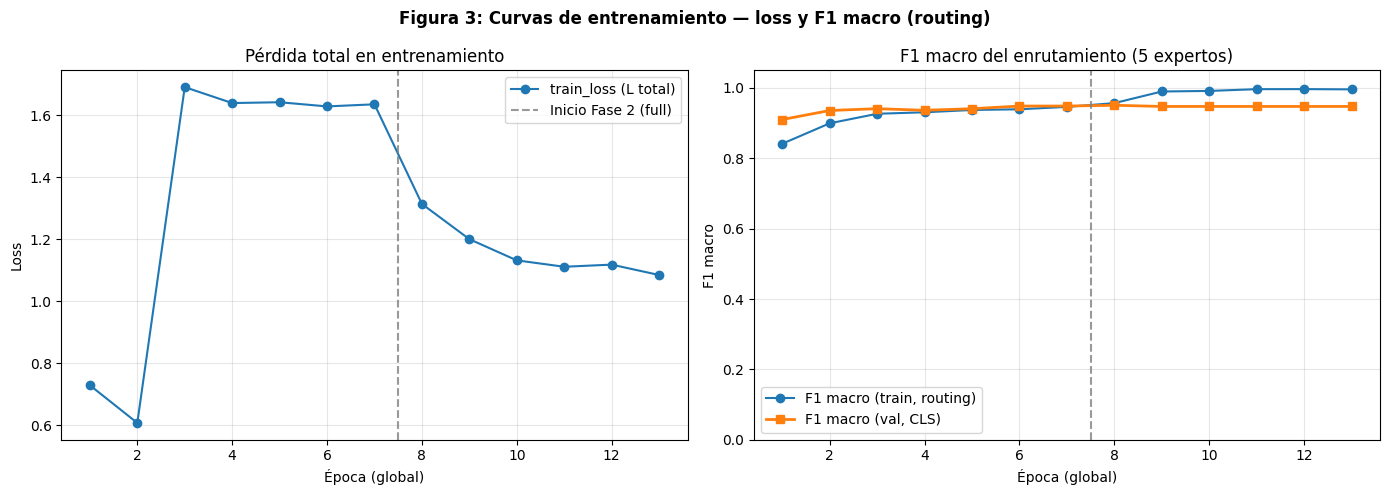

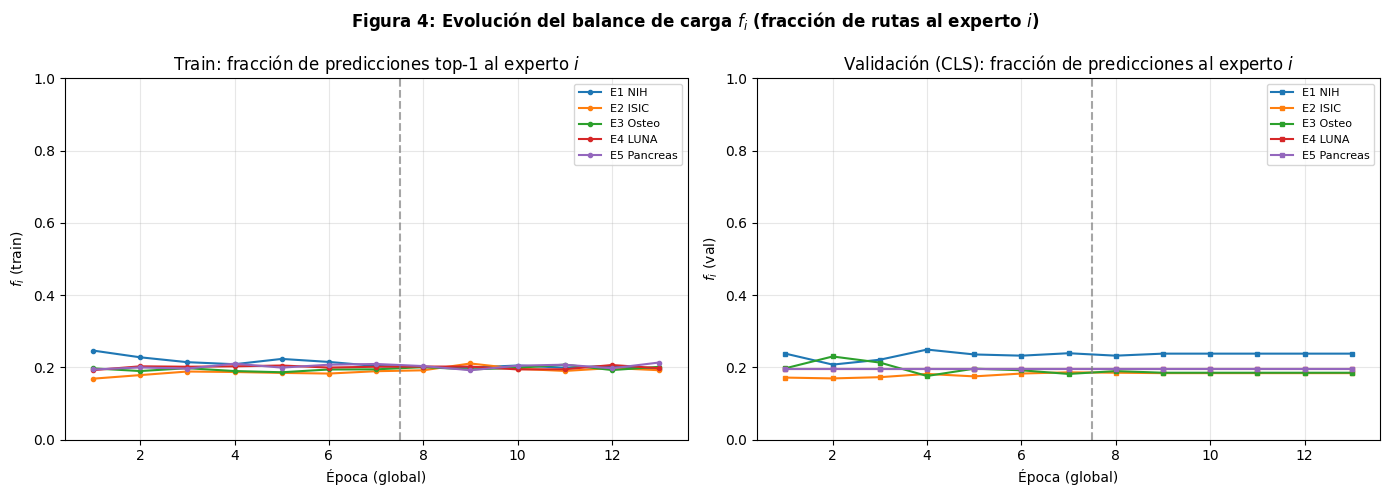

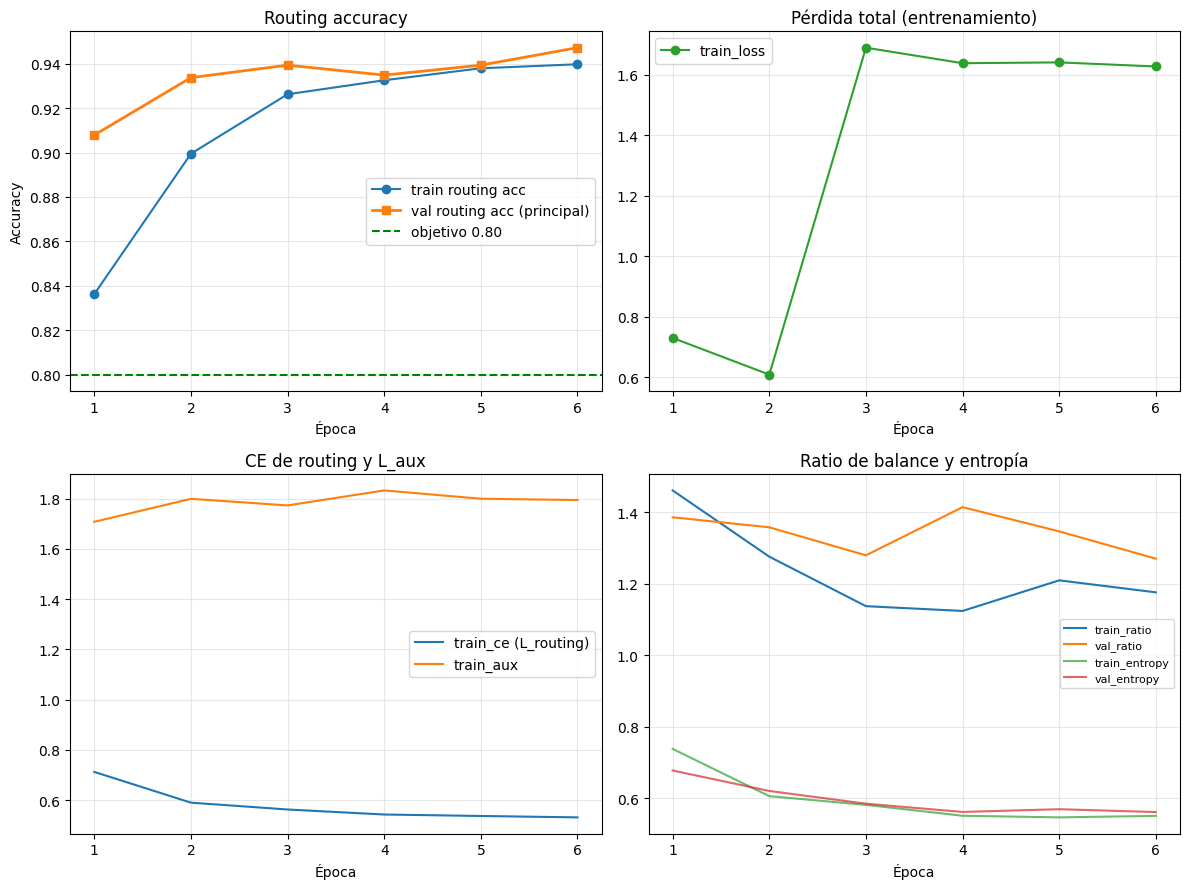


=== Métrica principal (última época) ===
Val routing accuracy: 0.9472  |  Objetivo > 0.80: SÍ


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

if "history_prof" not in globals() or history_prof is None:
    raise RuntimeError("Ejecuta antes la celda con fit_router_with_eval.")


def _macro_f1_from_cm_plot(cm):
    if cm is None:
        return float("nan")
    if isinstance(cm, torch.Tensor):
        cm = cm.float()
    else:
        cm = torch.as_tensor(cm, dtype=torch.float32)
    c = cm.shape[0]
    f1s = []
    for k in range(c):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        prec = tp / (tp + fp + 1e-9)
        rec = tp / (tp + fn + 1e-9)
        f1 = 2 * prec * rec / (prec + rec + 1e-9)
        f1s.append(float(f1.item()))
    return sum(f1s) / max(len(f1s), 1)


def _build_moe_history():
    """Concatena Fase 1 (history_base) + Fase 2 (history_ft) para curvas del MoE completo."""
    rows = []
    ep = 1
    if "history_base" in globals() and history_base:
        for h in history_base:
            d = dict(h)
            d["_ep_global"] = ep
            ep += 1
            rows.append(d)
    n_phase1 = len(rows)
    if "history_ft" in globals() and history_ft:
        for h in history_ft:
            d = dict(h)
            d["_ep_global"] = ep
            ep += 1
            rows.append(d)
    if rows:
        return rows, n_phase1
    for i, h in enumerate(history_prof):
        d = dict(h)
        d["_ep_global"] = i + 1
        rows.append(d)
    return rows, 0


hm, n_phase1 = _build_moe_history()
epochs_moe = [h["_ep_global"] for h in hm]

train_f1 = [h["train_f1_macro"] if "train_f1_macro" in h else _macro_f1_from_cm_plot(h.get("train_cm")) for h in hm]
val_f1 = [h["val_f1_macro"] if "val_f1_macro" in h else _macro_f1_from_cm_plot(h.get("val_cm")) for h in hm]

# --- Figura 3: pérdida y F1 macro (MoE completo: Fase 1 + Fase 2 si existen) ---
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle("Figura 3: Curvas de entrenamiento — loss y F1 macro (routing)", fontsize=12, fontweight="bold")
ax3a.plot(epochs_moe, [h["train_loss"] for h in hm], "o-", color="C0", label="train_loss (L total)")
ax3a.set_xlabel("Época (global)")
ax3a.set_ylabel("Loss")
ax3a.set_title("Pérdida total en entrenamiento")
ax3a.grid(True, alpha=0.3)
ax3a.legend()
if n_phase1 > 0 and len(hm) > n_phase1:
    ax3a.axvline(n_phase1 + 0.5, color="gray", linestyle="--", alpha=0.8, label="Inicio Fase 2 (full)")
    ax3a.legend()

ax3b.plot(epochs_moe, train_f1, "o-", label="F1 macro (train, routing)")
ax3b.plot(epochs_moe, val_f1, "s-", linewidth=2, label="F1 macro (val, CLS)")
ax3b.set_xlabel("Época (global)")
ax3b.set_ylabel("F1 macro")
ax3b.set_title("F1 macro del enrutamiento (5 expertos)")
ax3b.set_ylim(0, 1.05)
ax3b.grid(True, alpha=0.3)
ax3b.legend()
if n_phase1 > 0 and len(hm) > n_phase1:
    ax3b.axvline(n_phase1 + 0.5, color="gray", linestyle="--", alpha=0.8)
plt.tight_layout()
plt.show()

# --- Figura 4: fracción de carga f_i (Switch Transformer: % de asignaciones hard al experto i) ---
expert_names = ["E1 NIH", "E2 ISIC", "E3 Osteo", "E4 LUNA", "E5 Pancreas"]
fig4, (ax4t, ax4v) = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle(
    "Figura 4: Evolución del balance de carga $f_i$ (fracción de rutas al experto $i$)",
    fontsize=12,
    fontweight="bold",
)
for i in range(5):
    fi_tr = [h.get("train_route_pct", {}).get(i, 0) / 100.0 for h in hm]
    fi_va = [h.get("val_route_pct", {}).get(i, 0) / 100.0 for h in hm]
    ax4t.plot(epochs_moe, fi_tr, "o-", markersize=3, label=expert_names[i])
    ax4v.plot(epochs_moe, fi_va, "s-", markersize=3, label=expert_names[i])
ax4t.set_ylabel("$f_i$ (train)")
ax4t.set_xlabel("Época (global)")
ax4t.set_title("Train: fracción de predicciones top-1 al experto $i$")
ax4t.set_ylim(0, 1)
ax4t.grid(True, alpha=0.3)
ax4t.legend(fontsize=8, loc="upper right")
if n_phase1 > 0 and len(hm) > n_phase1:
    ax4t.axvline(n_phase1 + 0.5, color="gray", linestyle="--", alpha=0.7)

ax4v.set_ylabel("$f_i$ (val)")
ax4v.set_xlabel("Época (global)")
ax4v.set_title("Validación (CLS): fracción de predicciones al experto $i$")
ax4v.set_ylim(0, 1)
ax4v.grid(True, alpha=0.3)
ax4v.legend(fontsize=8, loc="upper right")
if n_phase1 > 0 and len(hm) > n_phase1:
    ax4v.axvline(n_phase1 + 0.5, color="gray", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

epochs = [h["epoch"] for h in history_prof]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.plot(epochs, [h["train_acc"] for h in history_prof], "o-", label="train routing acc")
ax.plot(epochs, [h["val_acc"] for h in history_prof], "s-", linewidth=2, label="val routing acc (principal)")
ax.axhline(0.80, color="green", linestyle="--", label="objetivo 0.80")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy")
ax.set_title("Routing accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, [h["train_loss"] for h in history_prof], "o-", color="C2", label="train_loss")
ax.set_xlabel("Época")
ax.set_title("Pérdida total (entrenamiento)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs, [h["train_ce"] for h in history_prof], label="train_ce (L_routing)")
ax.plot(epochs, [h["train_aux"] for h in history_prof], label="train_aux")
ax.set_xlabel("Época")
ax.set_title("CE de routing y L_aux")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(epochs, [h["train_ratio"] for h in history_prof], label="train_ratio")
ax.plot(epochs, [h["val_ratio"] for h in history_prof], label="val_ratio")
ax.plot(epochs, [h["train_entropy"] for h in history_prof], alpha=0.7, label="train_entropy")
ax.plot(epochs, [h["val_entropy"] for h in history_prof], alpha=0.7, label="val_entropy")
ax.set_xlabel("Época")
ax.set_title("Ratio de balance y entropía")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

last = history_prof[-1]
if ("val_cm" not in last) or ("train_cm" not in last):
    _with_cm = [h for h in history_prof if ("val_cm" in h and "train_cm" in h)]
    if _with_cm:
        last = _with_cm[-1]
        print("INFO: usando la ultima epoca con matrices disponibles para los heatmaps.")
    else:
        print("WARNING: history_prof no contiene val_cm/train_cm; se omitiran heatmaps.")

vacc = last.get("val_acc", float("nan"))
ok80 = "SÍ" if vacc >= 0.80 else "NO"
print("\n=== Métrica principal (última época) ===")
print(f"Val routing accuracy: {vacc:.4f}  |  Objetivo > 0.80: {ok80}")


def _to_numpy(cm):
    if isinstance(cm, torch.Tensor):
        return cm.detach().cpu().numpy()
    return np.asarray(cm)


labels = ["NIH", "ISIC", "Osteo", "LUNA", "Pancreas"]
if ("val_cm" in last) and ("train_cm" in last):
    val_cm = _to_numpy(last["val_cm"])
    tr_cm = _to_numpy(last["train_cm"])

    fig2, (axv, axt) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mat, title in [
        (axv, val_cm, "Validación (CLS) — pred vs verdadero"),
        (axt, tr_cm, "Entrenamiento (batches) — pred vs verdadero"),
    ]:
        im = ax.imshow(mat, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("Verdadero (índice experto)")
        ax.set_xlabel("Predicho (router)")
        vmax = float(mat.max()) if mat.size else 1.0
        for i in range(5):
            for j in range(5):
                ax.text(
                    j,
                    i,
                    str(int(mat[i, j])),
                    ha="center",
                    va="center",
                    color="w" if mat[i, j] > vmax / 2 else "k",
                    fontsize=9,
                )
    plt.tight_layout()
    plt.show()
else:
    print("WARNING: no hay matrices de confusion disponibles en history_prof para graficar.")


## Grad-CAM del router (atención sobre parches)

Mapa tipo **Grad-CAM** sobre la salida del **último bloque ViT** (antes de `router_head`): tres ejemplos **NIH (2D), ISIC (2D), LUNA16 (3D)**. Ejecuta tras tener `router` entrenado/cargado.


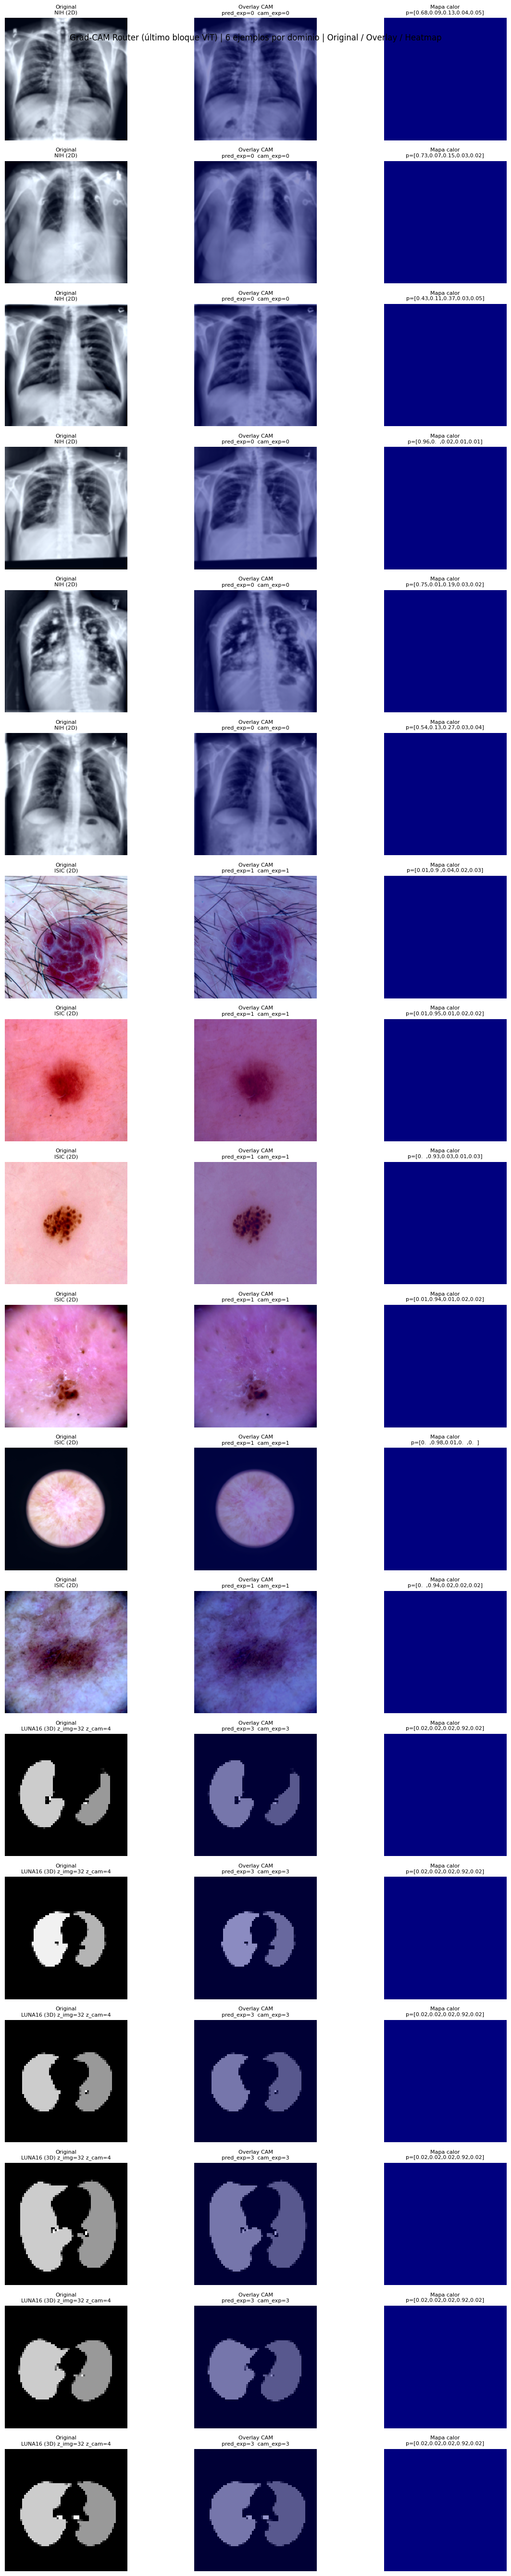

In [21]:
# --- Grad-CAM del router (galería amplia, estilo similar a Osteo) ---
# Requiere: router, DEVICE, DATASET_ROOTS, preprocessor, scan_dataset_files ya definidos.

import os
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def router_gradcam_last_block(router, batch_1sample, device, target_class=None):
    """Grad-CAM tipo token robusto sobre la salida del último bloque ViT del router."""
    router.eval()
    blk = router.vit.blocks[-1]
    acts = []
    grads = []

    # Si el backbone quedó congelado (head_only), habilitamos grad temporalmente para CAM.
    prev_req = [p.requires_grad for p in blk.parameters()]
    for p in blk.parameters():
        p.requires_grad_(True)

    def fh(_, __, out):
        out_t = out[0] if isinstance(out, (tuple, list)) else out
        acts.append(out_t)
        if out_t.requires_grad:
            out_t.register_hook(lambda g: grads.append(g))

    h = blk.register_forward_hook(fh)
    dev = torch.device(device)
    batch = [t.to(dev) for t in batch_1sample]

    try:
        with torch.enable_grad():
            router.zero_grad(set_to_none=True)
            logits, _ = router(batch)
            if target_class is None:
                target_class = int(logits.argmax(dim=-1).item())
            logits[0, target_class].backward()
    finally:
        h.remove()
        for p, rg in zip(blk.parameters(), prev_req):
            p.requires_grad_(rg)

    if not acts:
        raise RuntimeError("No se capturaron activaciones del último bloque ViT.")

    act = acts[0]
    grad = grads[0] if grads else torch.autograd.grad(
        logits[0, target_class], act, retain_graph=False, allow_unused=False
    )[0]

    cam = (grad * act).sum(dim=-1).clamp(min=0)
    cam = cam[0, 1:]  # quitamos token CLS
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
    pred = int(np.argmax(probs))
    return cam.detach().cpu(), target_class, pred, probs


def _infer_square_side(n_tokens):
    s = int(round(n_tokens ** 0.5))
    return s if s * s == n_tokens else None


def _infer_cube_side(n_tokens):
    s = int(round(n_tokens ** (1.0 / 3.0)))
    return s if s ** 3 == n_tokens else None


def _norm01(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


def _display_rgb_2d(tensor_chw):
    """Visualización robusta para 2D, evitando overlays demasiado azulados."""
    x = tensor_chw.detach().cpu().numpy().astype(np.float32)
    if x.ndim != 3:
        raise ValueError(f"Esperado [C,H,W], recibido {x.shape}")
    if x.shape[0] == 1:
        x = np.repeat(x, 3, axis=0)
    elif x.shape[0] > 3:
        x = x[:3]
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    return x.transpose(1, 2, 0)


def _middle_slice_rgb_3d(vol_chw):
    """vol_chw: [1,D,H,W] -> RGB del corte axial medio para visualización."""
    _, d, _, _ = vol_chw.shape
    z = d // 2
    sl = vol_chw[0, z].detach().cpu().numpy()
    sl = _norm01(sl)
    rgb = np.stack([sl, sl, sl], axis=-1)
    return rgb, z


def _heatmap2d_from_tokens(cam1d, out_hw):
    side = _infer_square_side(cam1d.numel())
    if side is None:
        raise ValueError(f"No es malla 2D cuadrada: n_tokens={cam1d.numel()}")
    g = cam1d.reshape(side, side).float().unsqueeze(0).unsqueeze(0)
    return F.interpolate(g, size=out_hw, mode="bilinear", align_corners=False)[0, 0].numpy()


def _heatmap2d_from_tokens3d_mid(cam1d, out_hw):
    side = _infer_cube_side(cam1d.numel())
    if side is None:
        raise ValueError(f"No es grilla 3D cúbica: n_tokens={cam1d.numel()}")
    vol = cam1d.reshape(side, side, side)
    z = side // 2
    sl = _norm01(vol[:, :, z].numpy())
    hm = F.interpolate(
        torch.from_numpy(sl).float().unsqueeze(0).unsqueeze(0),
        size=out_hw,
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()
    return hm, z


def _overlay(img_rgb, hm, alpha=0.42):
    hm_rgb = plt.cm.jet(np.clip(hm, 0, 1))[:, :, :3]
    return np.clip((1 - alpha) * img_rgb + alpha * hm_rgb, 0, 1)


def _sample_files(root, n=6, seed=42):
    files = scan_dataset_files(root)
    if not files:
        return []
    rng = random.Random(seed)
    if len(files) <= n:
        return files
    return rng.sample(files, n)


def plot_router_gradcam_gallery(router, device, n_per_domain=6, seed=42):
    """Galería: muchas muestras por dominio (Original | Grad-CAM overlay | mapa calor)."""
    domains = [
        ("NIH", "NIH (2D)"),
        ("ISIC", "ISIC (2D)"),
        ("LUNA16", "LUNA16 (3D)"),
    ]

    examples = []
    for key, title in domains:
        root = DATASET_ROOTS.get(key, (None, None))[0]
        if not root or not os.path.isdir(root):
            continue
        for fp in _sample_files(root, n=n_per_domain, seed=seed + len(examples)):
            examples.append((key, title, fp))

    if not examples:
        print("No se encontraron ejemplos para Grad-CAM.")
        return

    n_rows = len(examples)
    fig, axes = plt.subplots(n_rows, 3, figsize=(13, max(3 * n_rows, 6)))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, (key, title, fpath) in enumerate(examples):
        ax0, ax1, ax2 = axes[r]
        try:
            t = preprocessor(fpath)
            cam, tc, pred, probs = router_gradcam_last_block(router, [t], device)

            if t.ndim == 3:
                img = _display_rgb_2d(t)
                hm = _heatmap2d_from_tokens(cam, out_hw=(img.shape[0], img.shape[1]))
                ov = _overlay(img, hm)
                tdesc = f"{title}"
            elif t.ndim == 4:
                img, z_img = _middle_slice_rgb_3d(t)
                hm, z_cam = _heatmap2d_from_tokens3d_mid(cam, out_hw=(img.shape[0], img.shape[1]))
                ov = _overlay(img, hm)
                tdesc = f"{title} z_img={z_img} z_cam={z_cam}"
            else:
                raise ValueError(f"ndim no soportado: {t.ndim}")

            ax0.imshow(img)
            ax1.imshow(ov)
            ax2.imshow(hm, cmap="jet")

            probs_s = np.array2string(probs, precision=2, separator=",", suppress_small=True)
            ax0.set_title(f"Original\n{tdesc}", fontsize=8)
            ax1.set_title(f"Overlay CAM\npred_exp={pred}  cam_exp={tc}", fontsize=8)
            ax2.set_title(f"Mapa calor\np={probs_s}", fontsize=8)

        except Exception as e:
            msg = f"Error: {type(e).__name__}\n{e}"
            ax0.text(0.02, 0.5, msg, transform=ax0.transAxes, fontsize=8)
            ax1.text(0.02, 0.5, msg, transform=ax1.transAxes, fontsize=8)
            ax2.text(0.02, 0.5, msg, transform=ax2.transAxes, fontsize=8)

        short_name = os.path.basename(fpath)
        ax0.set_ylabel(short_name[:40], fontsize=7)
        ax0.axis("off")
        ax1.axis("off")
        ax2.axis("off")

    fig.suptitle(
        f"Grad-CAM Router (último bloque ViT) | {n_per_domain} ejemplos por dominio | Original / Overlay / Heatmap",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


if "router" not in dir() or router is None:
    print("Define `router` entrenado antes de ejecutar esta celda.")
elif "DEVICE" not in dir():
    print("Define DEVICE.")
else:
    # Ajusta n_per_domain si quieres más o menos ejemplos.
    plot_router_gradcam_gallery(router, DEVICE, n_per_domain=6, seed=42)



Recalculando train_cm con loader_prof (puede tardar)...
val_cm desde Z_val_np + router_head (coherente con val del entrenamiento).


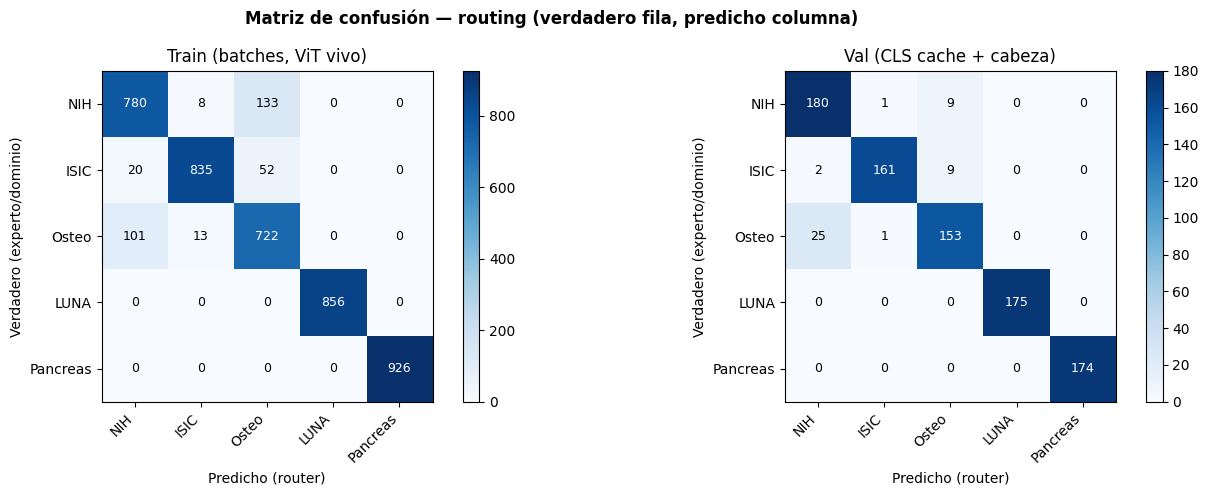

In [22]:
# --- Celda única: matriz de confusión de routing (train/val) sin re-entrenar si ya hay datos ---
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def _cm_safe_one_sample(model, loader, device):
    """Confusión routing: predicho (router) vs verdadero (dataset_id). Lotes mixtos 2D/3D OK."""
    model.eval()
    preds, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            samples, labels = batch[0], batch[1]
            if isinstance(labels, list):
                labels = torch.as_tensor(labels)
            labels = labels.long().cpu()
            for i, sample in enumerate(samples):
                x = sample.to(device, non_blocking=True)
                out = model([x])
                logits = out[0] if isinstance(out, (tuple, list)) else (
                    out.get("logits", out.get("router_logits")) if isinstance(out, dict) else out
                )
                preds.append(int(torch.argmax(logits, dim=1).item()))
                y_true.append(int(labels[i].item()))
    return confusion_matrix(y_true, preds, labels=list(range(5)))

def _to_numpy_cm(cm):
    if cm is None:
        return None
    if isinstance(cm, torch.Tensor):
        return cm.detach().cpu().numpy()
    return np.asarray(cm)

def _plot_cm_pair(tr_cm, va_cm, titles=("Train (batches)", "Val (CLS cache)")):
    labels = ["NIH", "ISIC", "Osteo", "LUNA", "Pancreas"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Matriz de confusión — routing (verdadero fila, predicho columna)", fontsize=12, fontweight="bold")
    for ax, mat, title in zip(axes, (tr_cm, va_cm), titles):
        im = ax.imshow(mat, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("Verdadero (experto/dominio)")
        ax.set_xlabel("Predicho (router)")
        vmax = float(mat.max()) if mat.size else 1.0
        for i in range(5):
            for j in range(5):
                ax.text(j, i, str(int(mat[i, j])), ha="center", va="center",
                        color="w" if mat[i, j] > vmax / 2 else "k", fontsize=9)
    plt.tight_layout()
    plt.show()

# 1) Preferir última época de history_prof con train_cm + val_cm
last = None
if "history_prof" in globals() and history_prof:
    for h in reversed(history_prof):
        if "train_cm" in h and "val_cm" in h:
            last = h
            break
    if last is None:
        last = history_prof[-1]

tr_cm = None
va_cm = None
if last is not None and "train_cm" in last and "val_cm" in last:
    tr_cm = _to_numpy_cm(last["train_cm"])
    va_cm = _to_numpy_cm(last["val_cm"])
    print("Matrices desde history_prof (última época con ambas CM o última fila).")
elif last is not None and "val_cm" in last:
    va_cm = _to_numpy_cm(last["val_cm"])
    print("Solo val_cm en history; train se recalcula abajo si hace falta.")

# 2) Si falta algo: recalcular (router en memoria; no hace falta re-entrenar si ya está cargado)
_dev = DEVICE if "DEVICE" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")

def _val_cm_from_cls_cache():
    """Igual que eval_router_on_cls: cabeza sobre Z_val (CLS cacheado)."""
    if not all(k in globals() for k in ("router", "Z_val_np", "y_val_np")):
        return None
    router.eval()
    Z = torch.tensor(Z_val_np, dtype=torch.float32, device=_dev)
    y = torch.tensor(y_val_np, dtype=torch.long, device=_dev)
    with torch.no_grad():
        logits = router.router_head(Z)
        preds = logits.argmax(dim=1)
    return confusion_matrix(y.cpu().numpy(), preds.cpu().numpy(), labels=list(range(5)))

if "router" in globals() and "loader_prof" in globals():
    if tr_cm is None:
        print("Recalculando train_cm con loader_prof (puede tardar)...")
        tr_cm = _cm_safe_one_sample(router, loader_prof, _dev)
    if va_cm is None:
        va_cm = _val_cm_from_cls_cache()
        if va_cm is not None:
            print("val_cm desde Z_val_np + router_head (coherente con val del entrenamiento).")
        else:
            print("Recalculando val_cm con loader_prof (fallback; no hay Z_val_np).")
            va_cm = _cm_safe_one_sample(router, loader_prof, _dev)
else:
    print("ERROR: necesita router y loader_prof (y Z_val_np/y_val_np para val tipo CLS).")

if tr_cm is not None and va_cm is not None:
    _plot_cm_pair(tr_cm, va_cm, titles=("Train (batches, ViT vivo)", "Val (CLS cache + cabeza)"))
else:
    print("No se pudo obtener matrices completas.")